In [2]:
import netCDF4
import os
import matplotlib.pyplot as plt

file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'pfts1d_itype_lunit', 'pfts1d_itype_col',
             'cols1d_wtgcell', 'pfts1d_wtcol', 'FCEV', 'FCTR']

data = {}

for scenario in scenarios:
    data[scenario] = {}
    for variable in variables:
        nc_file = os.path.join(file_path, scenario, file_name, f"{scenario}.clm2.h0.{time_stamp}")
        with netCDF4.Dataset(nc_file, 'r') as ds:
            data[scenario][variable] = ds.variables[variable][:]

print(data)


{'MEAN_final_2001_to_2011': {'pfts1d_ixy': masked_array(data=[  1,   1,   2, ..., 135, 135, 135],
             mask=False,
       fill_value=999999), 'pfts1d_jxy': masked_array(data=[ 1,  1,  1, ..., 93, 93, 93],
             mask=False,
       fill_value=999999), 'grid1d_lat': masked_array(data=[-90.        , -90.        , -90.        , ...,
                    84.31578947,  84.31578947,  84.31578947],
             mask=False,
       fill_value=1e+20), 'grid1d_lon': masked_array(data=[  0. ,   2.5,   5. , ..., 330. , 332.5, 335. ],
             mask=False,
       fill_value=1e+20), 'area': masked_array(
  data=[[242.11138916015625, 242.11138916015625, 242.11138916015625, ...,
         242.11138916015625, 242.11138916015625, 242.11138916015625],
        [1936.4940185546875, 1936.4940185546875, 1936.4940185546875, ...,
         1936.4940185546875, 1936.4940185546875, 1936.4940185546875],
        [3870.87060546875, 3870.87060546875, 3870.87060546875, ...,
         3870.87060546875, 3870.

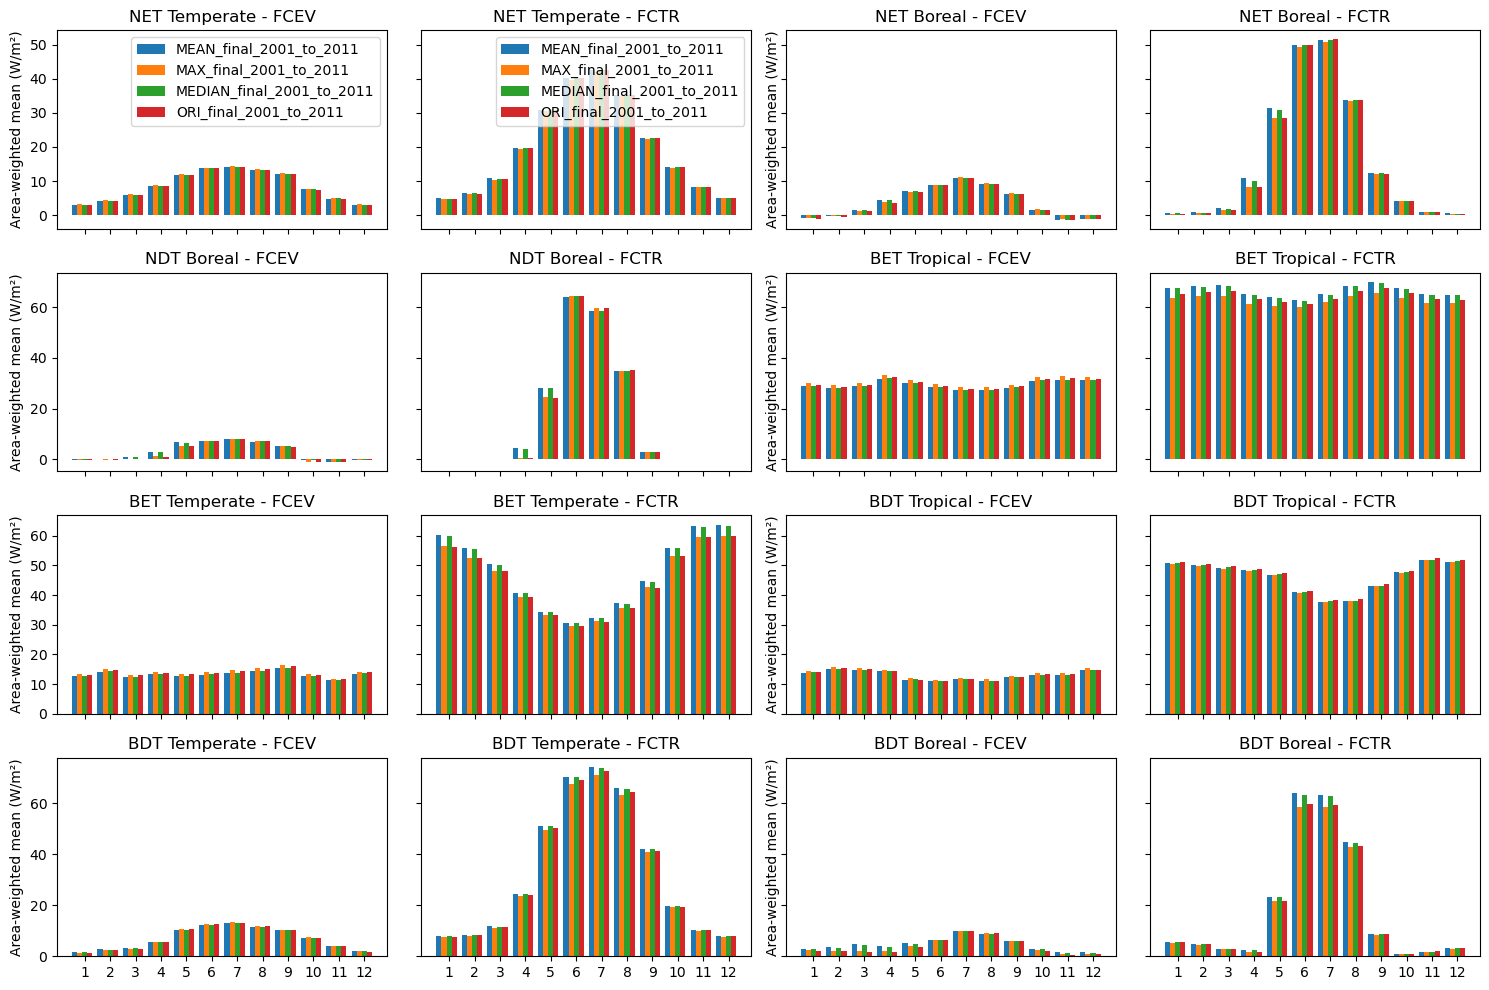

In [6]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt

file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'FCEV', 'FCTR', 'QVEGE', 'QVEGT']

data = {}

for scenario in scenarios:
    data[scenario] = {}
    for variable in variables:
        nc_file = os.path.join(file_path, scenario, file_name, f"{scenario}.clm2.h0.{time_stamp}")
        with netCDF4.Dataset(nc_file, 'r') as ds:
            data[scenario][variable] = ds.variables[variable][:]

# Calculate area-weighted mean evaporation and transpiration for each PFT
area = data[scenarios[0]]['area']
pfts1d_itype_veg = data[scenarios[0]]['pfts1d_itype_veg']
pfts1d_ixy = data[scenarios[0]]['pfts1d_ixy']
pfts1d_jxy = data[scenarios[0]]['pfts1d_jxy']
pfts1d_wtgcell = data[scenarios[0]]['pfts1d_wtgcell']
unique_pfts = np.arange(1, 9)  # PFTs from 1 to 8

monthly_mean = {}

for scenario in scenarios:
    monthly_mean[scenario] = {}
    for pft in unique_pfts:
        pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
        pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weight = pfts1d_wtgcell[pft_indexes]
        
        pft_area = pft_area*weight
        fcev = data[scenario]['FCEV'][:, pft_indexes]
        fctr = data[scenario]['FCTR'][:, pft_indexes]

        weighted_fcev = np.average(fcev, axis=1, weights=pft_area)
        weighted_fctr = np.average(fctr, axis=1, weights=pft_area)

        monthly_mean[scenario][pft] = {'FCEV': weighted_fcev, 'FCTR': weighted_fctr}
        
        

# PFT names and numbers
pft_names = {
    "NET Temperate": 1,
    "NET Boreal": 2,
    "NDT Boreal": 3,
    "BET Tropical": 4,
    "BET Temperate": 5,
    "BDT Tropical": 6,
    "BDT Temperate": 7,
    "BDT Boreal": 8,
}

unique_pfts = pft_names.keys()



monthly_mean = {}

pfts1d_itype_veg = data[scenario]['pfts1d_itype_veg']
for scenario in scenarios:
    monthly_mean[scenario] = {}
    for pft_name in unique_pfts:
        pft = pft_names[pft_name]
        pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
        pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weight = pfts1d_wtgcell[pft_indexes]
        
        pft_area = pft_area*weight
        fcev = data[scenario]['FCEV'][:, pft_indexes]
        fctr = data[scenario]['FCTR'][:, pft_indexes]

        weighted_fcev = np.average(fcev, axis=1, weights=pft_area)
        weighted_fctr = np.average(fctr, axis=1, weights=pft_area)

        monthly_mean[scenario][pft_name] = {'FCEV': weighted_fcev, 'FCTR': weighted_fctr}

# Visualize the results
n_months = 12
n_scenarios = len(scenarios)
n_pfts = len(unique_pfts)
variables = ['FCEV', 'FCTR']

n_rows = 4
n_cols = 4

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10), sharex=True, sharey='row', dpi=100)

for pft_idx, pft_name in enumerate(unique_pfts):
    for var_idx, variable in enumerate(variables):
        row = pft_idx // (n_cols // 2)
        col = pft_idx % (n_cols // 2) * 2 + var_idx
        ax = axes[row, col]

        # Create bar plots for each scenario
        bar_width = 0.2
        x_positions = np.arange(n_months)
        for i, scenario in enumerate(scenarios):
            mean_values = monthly_mean[scenario][pft_name][variable]
            positions = x_positions + i * bar_width
            ax.bar(positions, mean_values, width=bar_width, label=scenario)
            ax.set_title(f"{pft_name} - {variable}")
        if col % 2 == 0:
            ax.set_ylabel("Area-weighted mean (W/m²)")

        if pft_idx == 0:
            ax.legend()

    ax.set_xticks(x_positions + bar_width * n_scenarios / 2)
    ax.set_xticklabels([f"{i + 1}" for i in range(n_months)])

plt.tight_layout()
plt.show()

In [4]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import interp2d

file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}
CTH = {}
for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables['MONTHLY_HEIGHT_TOP'][0][1:9, :, :]
        if scenario == 'mean':
            lat = ds.variables['LATIXY'][:]
            lon = ds.variables['LONGXY'][:]
            pct_nat_pft = ds.variables['PCT_NAT_PFT'][:][ :, :]
            pct_nat_pft = 1 * pct_nat_pft[1:9][:,:] / sum(pct_nat_pft[1:9][:,:])
        data[scenario] = data[scenario] * pct_nat_pft
        CTH[scenario] = sum(data[scenario][1:9][ :, :])

# Interpolate the missing data
lon_new = np.linspace(lon[0], lon[-1], len(lon)*4)
lat_new = np.linspace(lat[0], lat[-1], len(lat)*4)
mean_canopy_top_height_interp = interp2d(lon, lat, mean_canopy_top_height, kind='linear')(lon_new, lat_new)
canopy_top_height_deviation_interp = interp2d(lon, lat, canopy_top_height_deviation, kind='linear')(lon_new, lat_new)

# Calculate the multi-scenario mean canopy top height and deviation
mean_canopy_top_height = np.mean([CTH[scenario] for scenario in scenarios], axis=0)
canopy_top_height_deviation = np.std([CTH[scenario] for scenario in scenarios], axis=0)

# Define the map projection
projection = ccrs.PlateCarree()

# Create a figure and axis
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=200, subplot_kw=dict(projection=projection))

# Plot the mean canopy top height as a filled contour
levels = np.arange(0, 40)
cmap = plt.get_cmap('YlGn')
cs = ax1.contourf(lon_new, lat_new, mean_canopy_top_height_interp, levels=levels, cmap=cmap, extend='both', transform=projection)

# Add colorbar below the plot
cbar1 = plt.colorbar(cs, orientation='horizontal', shrink=0.8, pad=0.05, label='Canopy Top Height (m)', ax=ax1)

# Add contour lines for deviation
dev_levels = np.arange(0, 10)
dev_cs = ax2.contourf(lon_new, lat_new, canopy_top_height_deviation_interp, dev_levels, cmap='turbo', extend='both', transform=projection)
cbar2 = plt.colorbar(dev_cs, orientation='horizontal', shrink=0.8, pad=0.05, label='Deviation of Canopy Top Height (m)', ax=ax2)

# Add map features
ax1.add_feature(cfeature.COASTLINE)
ax2.add_feature(cfeature.COASTLINE)

# Set the title
ax1.set_title('Mean Canopy Top Height')
ax2.set_title('Deviation of Canopy Top Height')

plt.show()

NameError: name 'mean_canopy_top_height' is not defined

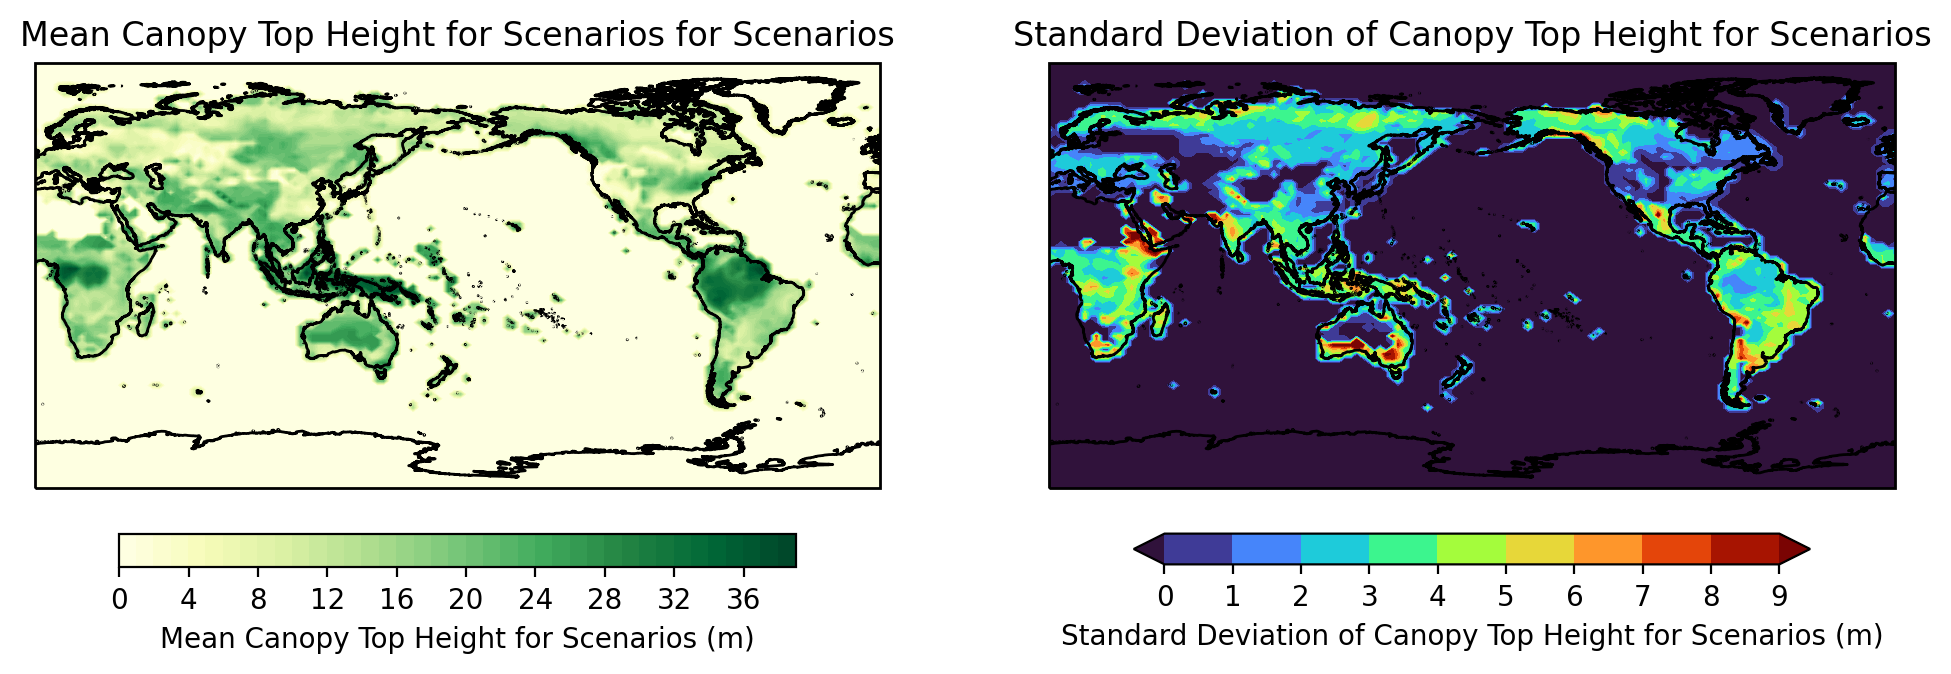

In [34]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}
CTH = {}
for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables['MONTHLY_HEIGHT_TOP'][0][1:9, :, :]
        if scenario == 'mean':
            lat = ds.variables['LATIXY'][:]
            lon = ds.variables['LONGXY'][:]
            pct_nat_pft = ds.variables['PCT_NAT_PFT'][:][ :, :]
            pct_nat_pft = 1 * pct_nat_pft[1:9][:,:] / sum(pct_nat_pft[1:9][:,:])
        data[scenario] = data[scenario] * pct_nat_pft
        CTH[scenario] = sum(data[scenario][1:9][ :, :])

lon = lon
# Calculate the multi-scenario mean canopy top height and deviation
mean_canopy_top_height = np.mean([CTH[scenario] for scenario in scenarios], axis=0)
canopy_top_height_deviation = np.std([CTH[scenario] for scenario in scenarios], axis=0)

lon = lon-180
# Define the map projection
projection = ccrs.PlateCarree(central_longitude=180)

# Create a figure and axis
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), dpi=200, subplot_kw=dict(projection=projection))

# Plot the mean canopy top height as a filled contour
levels = np.arange(0, 40)
cmap = plt.get_cmap('YlGn')
cs = ax1.contourf(lon, lat, mean_canopy_top_height, levels=levels, cmap=cmap, transform=projection)

# Add colorbar below the plot
cbar1 = plt.colorbar(cs, orientation='horizontal', shrink=0.8, pad=0.05, label='Mean Canopy Top Height for Scenarios (m)', ax=ax1)

# Add contour lines for deviation
dev_levels = np.arange(0, 10)
dev_cs = ax2.contourf(lon, lat, canopy_top_height_deviation, dev_levels, cmap='turbo', extend='both', transform=projection)

# Add colorbar below the plot
cbar2 = plt.colorbar(dev_cs, orientation='horizontal', shrink=0.8, pad=0.05, label='Standard Deviation of Canopy Top Height for Scenarios (m)', ax=ax2)

# Add map features
ax1.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='black')
ax2.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1, edgecolor='black')

# Set the title
ax1.set_title('Mean Canopy Top Height for Scenarios for Scenarios')
ax2.set_title('Standard Deviation of Canopy Top Height for Scenarios')

plt.show()

In [21]:
lon.max()

177.5

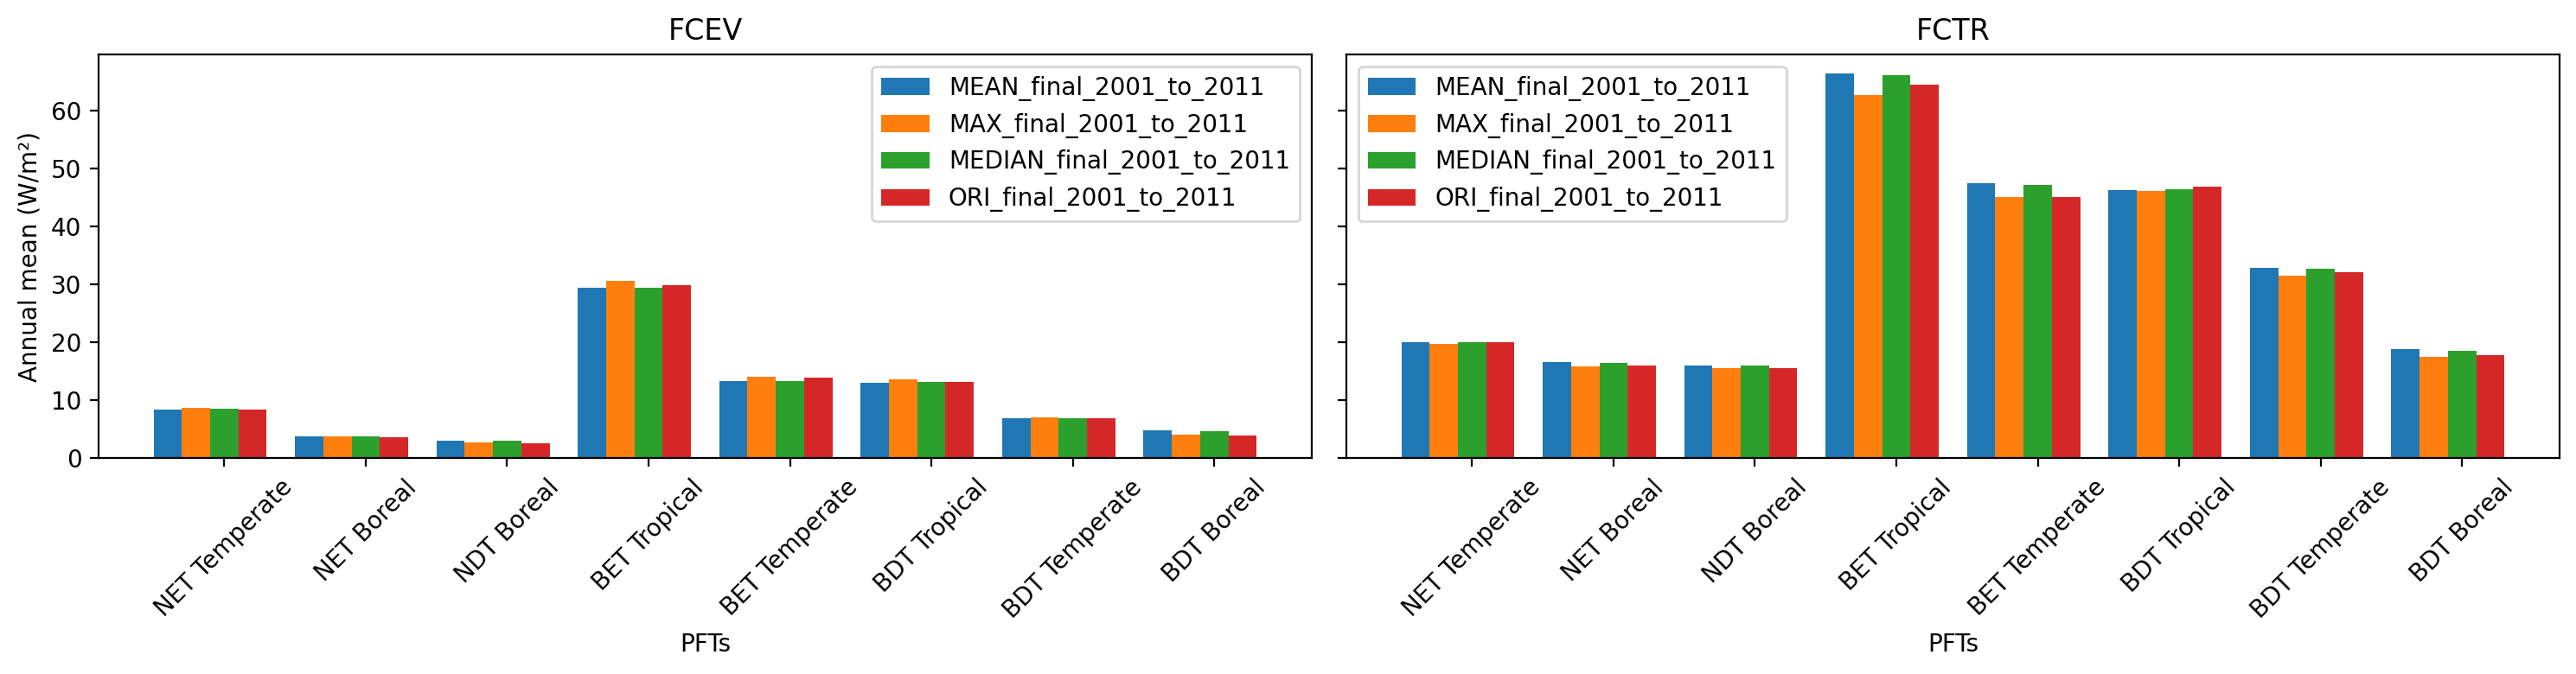

In [9]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt

file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'FCEV', 'FCTR', 'QVEGE', 'QVEGT']

data = {}

for scenario in scenarios:
    data[scenario] = {}
    for variable in variables:
        nc_file = os.path.join(file_path, scenario, file_name, f"{scenario}.clm2.h0.{time_stamp}")
        with netCDF4.Dataset(nc_file, 'r') as ds:
            data[scenario][variable] = ds.variables[variable][:]

            # Calculate area-weighted mean evaporation and transpiration for each PFT
area = data[scenarios[0]]['area']
pfts1d_itype_veg = data[scenarios[0]]['pfts1d_itype_veg']
pfts1d_ixy = data[scenarios[0]]['pfts1d_ixy']
pfts1d_jxy = data[scenarios[0]]['pfts1d_jxy']
pfts1d_wtgcell = data[scenarios[0]]['pfts1d_wtgcell']
unique_pfts = np.arange(1, 9)  # PFTs from 1 to 8

# PFT names and numbers
pft_names = {
    "NET Temperate": 1,
    "NET Boreal": 2,
    "NDT Boreal": 3,
    "BET Tropical": 4,
    "BET Temperate": 5,
    "BDT Tropical": 6,
    "BDT Temperate": 7,
    "BDT Boreal": 8,
}

unique_pfts = pft_names.keys()

annual_mean = {}

for scenario in scenarios:
    annual_mean[scenario] = {}
    for pft_name in unique_pfts:
        pft = pft_names[pft_name]
        pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
        pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weight = pfts1d_wtgcell[pft_indexes]
        
        pft_area = pft_area*weight
        fcev = data[scenario]['FCEV'][:, pft_indexes]
        fctr = data[scenario]['FCTR'][:, pft_indexes]

        weighted_fcev = np.average(fcev, axis=1, weights=pft_area)
        weighted_fctr = np.average(fctr, axis=1, weights=pft_area)

        annual_mean[scenario][pft_name] = {'FCEV': np.mean(weighted_fcev), 'FCTR': np.mean(weighted_fctr)}

# Visualize the results
n_pfts = len(unique_pfts)
variables = ['FCEV', 'FCTR']

fig, axes = plt.subplots(1, len(variables), figsize=(15, 4), sharey=True, dpi=200)


for var_idx, variable in enumerate(variables):
    ax = axes[var_idx]

    # Create bar plots for each scenario
    bar_width = 0.2
    x_positions = np.arange(n_pfts)
    for i, scenario in enumerate(scenarios):
        annual_means = [annual_mean[scenario][pft][variable] for pft in unique_pfts]
        positions = x_positions + i * bar_width
        ax.bar(positions, annual_means, width=bar_width, label=scenario)

    ax.set_title(variable)
    ax.set_xticks(x_positions + bar_width * n_scenarios / 2)
    ax.set_xticklabels(list(unique_pfts), rotation=45)
    ax.set_xlabel("PFTs")
    ax.legend()
    
    if var_idx == 0:
        ax.set_ylabel("Annual mean (W/m²)")

plt.tight_layout()
plt.show()

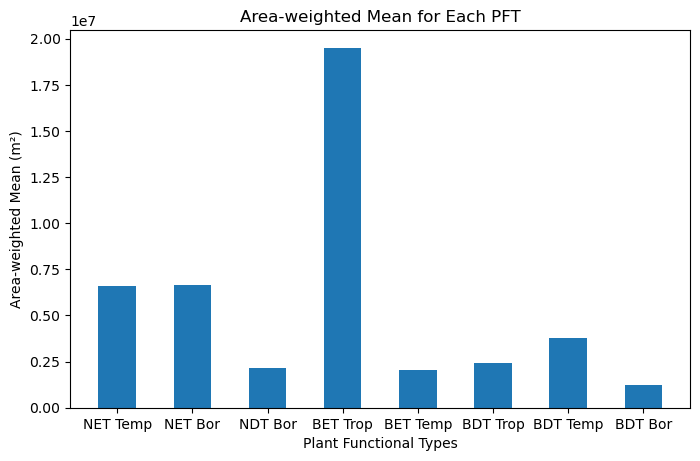

In [7]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt

file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'FCEV', 'FCTR', 'QVEGE', 'QVEGT']

data = {}

for scenario in scenarios:
    data[scenario] = {}
    for variable in variables:
        nc_file = os.path.join(file_path, scenario, file_name, f"{scenario}.clm2.h0.{time_stamp}")
        with netCDF4.Dataset(nc_file, 'r') as ds:
            data[scenario][variable] = ds.variables[variable][:]

# Calculate the area-weighted mean evaporation and transpiration for each PFT
area = data[scenarios[0]]['area']
pfts1d_itype_veg = data[scenarios[0]]['pfts1d_itype_veg']
pfts1d_ixy = data[scenarios[0]]['pfts1d_ixy']
pfts1d_jxy = data[scenarios[0]]['pfts1d_jxy']
pfts1d_wtgcell = data[scenarios[0]]['pfts1d_wtgcell']
unique_pfts = np.arange(1, 9)  # PFTs from 1 to 8

# Calculate the area-weighted mean for each PFT
pft_areas = []
for pft in unique_pfts:
    pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
    pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
    weight = pfts1d_wtgcell[pft_indexes]
    pft_areas.append(np.sum(pft_area * weight))

# Plot the area-weighted mean for each PFT
fig, ax = plt.subplots(figsize=(8, 5),dpi=100)
x_pos = np.arange(len(unique_pfts))
bar_width = 0.5
ax.bar(x_pos, pft_areas, width=bar_width, align='center')
ax.set_xticks(x_pos)
ax.set_xticklabels(['NET Temp', 'NET Bor', 'NDT Bor', 'BET Trop', 'BET Temp', 'BDT Trop', 'BDT Temp', 'BDT Bor'])
ax.set_xlabel('Plant Functional Types')
ax.set_ylabel('Area-weighted Mean (m²)')
ax.set_title('Area-weighted Mean for Each PFT')
plt.show()


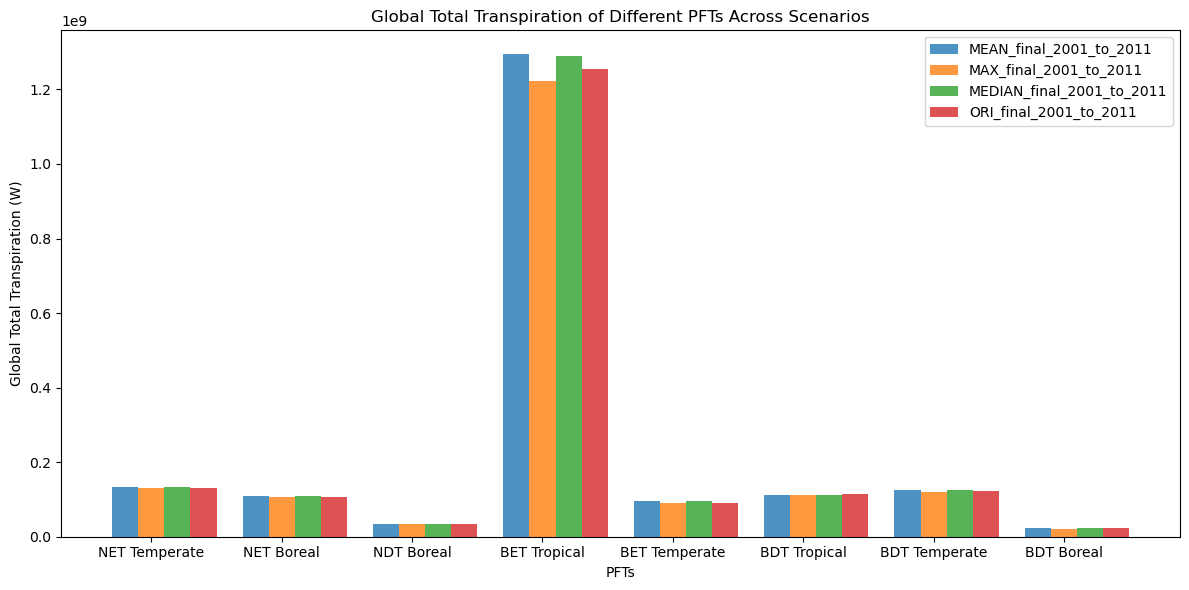

In [20]:
# Calculate the global total for each scenario
global_totals_TR = {}
file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'FCEV', 'FCTR', 'QVEGE', 'QVEGT']

for scenario in scenarios:
    global_totals_TR[scenario] = {}
    for pft_name in pft_names:
        pft = pft_names[pft_name]
        pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
        pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weight = pfts1d_wtgcell[pft_indexes]
        pft_area = pft_area * weight
        fctr = data[scenario]['FCTR'][:, pft_indexes]
        
        global_totals_TR[scenario][pft_name] = np.sum(pft_area * np.mean(fctr, axis=0))

# Calculate the differences between scenarios
reference_scenario = 'ORI_final_2001_to_2011'
differences = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    differences[scenario] = {}
    for pft_name in pft_names:
        differences[scenario][pft_name] = global_totals_TR[scenario][pft_name] - global_totals_TR[reference_scenario][pft_name]

"""
# Output results
print("Global totals:")
for scenario in scenarios:
    print(f"{scenario}:")
    for pft_name in pft_names:
        print(f"{pft_name}: {global_totals_TR[scenario][pft_name]}")
    print()

print("Differences:")
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    print(f"{scenario}:")
    for pft_name in pft_names:
        print(f"{pft_name}: {differences[scenario][pft_name]}")
    print()
"""

import matplotlib.pyplot as plt
import numpy as np

num_pfts = len(pft_names)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_pfts)

plt.figure(figsize=(12, 6), dpi =100)

for i, scenario in enumerate(scenarios):
    pft_values = [global_totals_TR[scenario][pft_name] for pft_name in pft_names]
    plt.bar(index + i * bar_width, pft_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('PFTs')
plt.ylabel('Global Total Transpiration (W)')
plt.title('Global Total Transpiration of Different PFTs Across Scenarios')
plt.xticks(index + bar_width, pft_names)
plt.legend()

plt.tight_layout()
plt.show()


Boreal:
MEAN_final_2001_to_2011: 168306915.5019762
MAX_final_2001_to_2011: 161020477.5318805
MEDIAN_final_2001_to_2011: 167163436.4718805
ORI_final_2001_to_2011: 162453026.42646822

Temperate:
MEAN_final_2001_to_2011: 353315868.1976705
MAX_final_2001_to_2011: 341621649.86068594
MEDIAN_final_2001_to_2011: 352311582.8503621
ORI_final_2001_to_2011: 345198983.13377786

Tropical:
MEAN_final_2001_to_2011: 1406203368.5265923
MAX_final_2001_to_2011: 1334372360.1713295
MEDIAN_final_2001_to_2011: 1401041327.4704354
ORI_final_2001_to_2011: 1368544834.6807985



C:\Users\hyou34\AppData\Local\miniconda3\envs\py36\lib\site-packages\ipykernel_launcher.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator


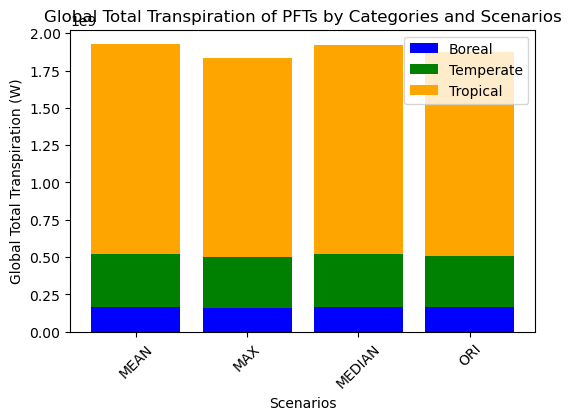

In [21]:
# Define the category dictionary
categories = {
    "Boreal": ["NDT Boreal", "BDT Boreal", "NET Boreal"],
    "Temperate": ["BET Temperate", "BDT Temperate", "NET Temperate"],
    "Tropical": ["BET Tropical", "BDT Tropical"],
}

# Calculate the total value of each category
category_totals = {}
for category, pft_list in categories.items():
    category_totals[category] = {}
    for scenario in scenarios:
        category_totals[category][scenario] = sum(
            [global_totals_TR[scenario][pft_name] for pft_name in pft_list]
        )

# Output results
for category in categories:
    print(f"{category}:")
    for scenario in scenarios:
        print(f"{scenario}: {category_totals[category][scenario]}")
    print()

import matplotlib.pyplot as plt

# Set scene labels and colors
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
colors = {'Boreal': 'blue', 'Temperate': 'green', 'Tropical': 'orange'}
scenarios_tag = ['MEAN', 'MAX', 'MEDIAN', 'ORI']
# Initialize the data for the stacked bar chart
bottoms = {scenario: 0 for scenario in scenarios}

# Draw stacked bars
fig, ax = plt.subplots(dpi = 100)
for category in categories:
    values = [category_totals[category][scenario] for scenario in scenarios]
    ax.bar(scenarios, values, bottom=[bottoms[scenario] for scenario in scenarios], label=category, color=colors[category])
    for scenario in scenarios:
        bottoms[scenario] += category_totals[category][scenario]
    ax.set_xticklabels(list(scenarios_tag), rotation=45)
    
# Set up titles, labels and legends
ax.set_title('Global Total Transpiration of PFTs by Categories and Scenarios')
ax.set_xlabel('Scenarios')
ax.set_ylabel('Global Total Transpiration (W)')
ax.legend()

# Display graphics
plt.show()


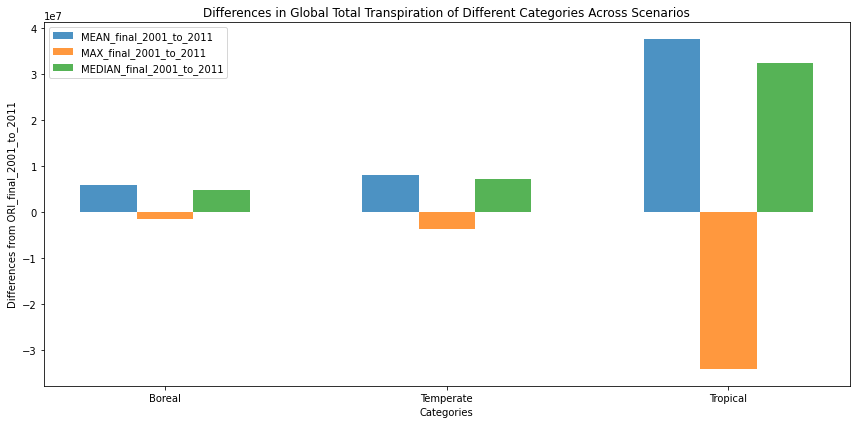

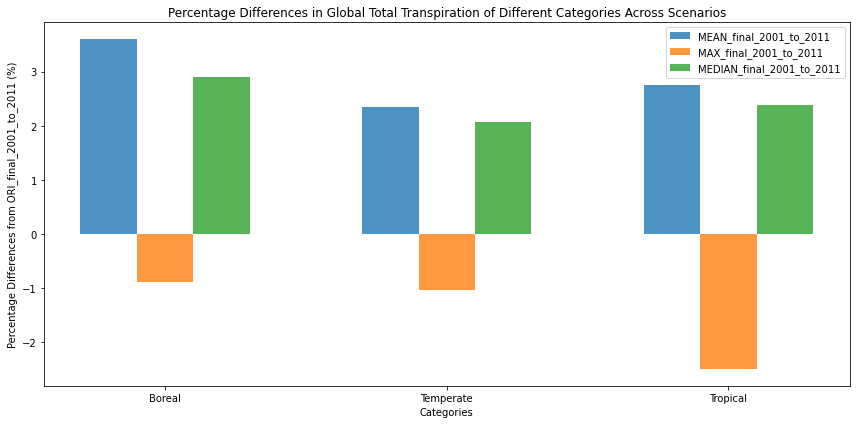

In [22]:
# 1. create a dictionary that maps each PFT to the corresponding category
pft_categories = {}
for pft_name in pft_names:
    if "Boreal" in pft_name:
        pft_categories[pft_name] = "Boreal"
    elif "Temperate" in pft_name:
        pft_categories[pft_name] = "Temperate"
    elif "Tropical" in pft_name:
        pft_categories[pft_name] = "Tropical"

# 2. Calculate global totals for each category
category_totals = {}
for scenario in scenarios:
    category_totals[scenario] = {"Boreal": 0, "Temperate": 0, "Tropical": 0}
    for pft_name in pft_names:
        category = pft_categories[pft_name]
        category_totals[scenario][category] += global_totals_TR[scenario][pft_name]

# 3. calculate the differences between scenarios
reference_scenario = 'ORI_final_2001_to_2011'
category_differences = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    category_differences[scenario] = {}
    for category in ["Boreal", "Temperate", "Tropical"]:
        category_differences[scenario][category] = category_totals[scenario][category] - category_totals[reference_scenario][category]

# 4. visualization results
categories = ["Boreal", "Temperate", "Tropical"]
num_categories = len(categories)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_categories)

plt.figure(figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    if scenario == reference_scenario:
        continue
    category_values = [category_differences[scenario][category] for category in categories]
    plt.bar(index + i * bar_width, category_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('Categories')
plt.ylabel('Differences from ORI_final_2001_to_2011')
plt.title('Differences in Global Total Transpiration of Different Categories Across Scenarios')
plt.xticks(index + bar_width, categories)
plt.legend()

plt.tight_layout()
plt.show()

# 5. Calculate the difference between scenarios (percentage)
reference_scenario = 'ORI_final_2001_to_2011'
category_differences_percentage = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    category_differences_percentage[scenario] = {}
    for category in ["Boreal", "Temperate", "Tropical"]:
        difference = category_totals[scenario][category] - category_totals[reference_scenario][category]
        category_differences_percentage[scenario][category] = (difference / category_totals[reference_scenario][category]) * 100

# 6. visualization results
categories = ["Boreal", "Temperate", "Tropical"]
num_categories = len(categories)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_categories)

plt.figure(figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    if scenario == reference_scenario:
        continue
    category_values = [category_differences_percentage[scenario][category] for category in categories]
    plt.bar(index + i * bar_width, category_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('Categories')
plt.ylabel('Percentage Differences from ORI_final_2001_to_2011 (%)')
plt.title('Percentage Differences in Global Total Transpiration of Different Categories Across Scenarios')
plt.xticks(index + bar_width, categories)
plt.legend()

plt.tight_layout()
plt.show()


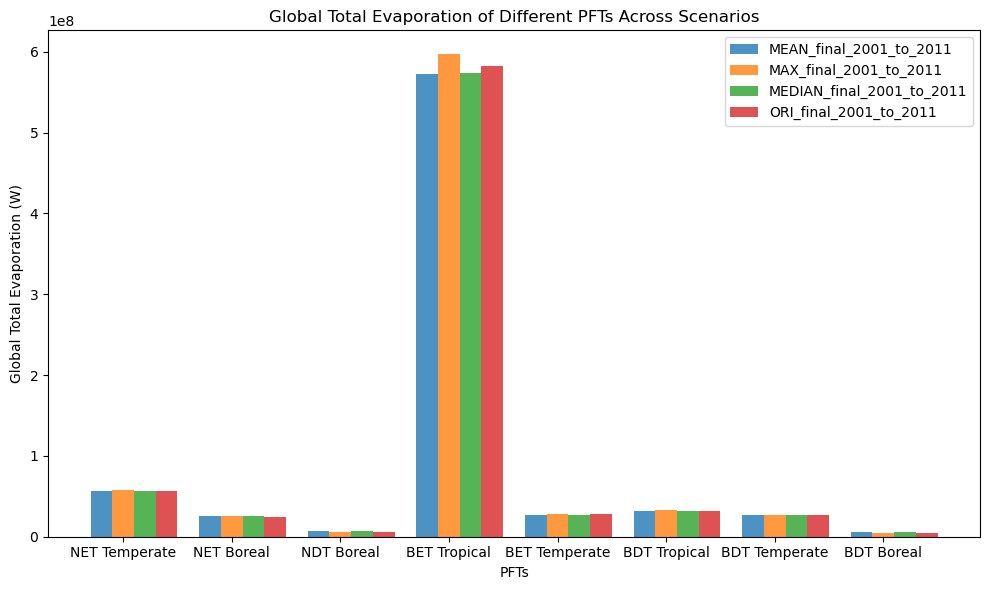

In [23]:
# Calculate the global total for each scenario
global_totals_EV = {}
file_path = 'H:/clm_output/withpft/'
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
file_name = 'lnd/hist/'
time_stamp = '2010-02-01-00000.nc'

variables = ['pfts1d_ixy', 'pfts1d_jxy', 'grid1d_lat', 'grid1d_lon', 'area',
             'pfts1d_itype_veg', 'pfts1d_wtgcell', 'FCEV', 'FCTR', 'QVEGE', 'QVEGT']

for scenario in scenarios:
    global_totals_EV[scenario] = {}
    for pft_name in pft_names:
        pft = pft_names[pft_name]
        pft_indexes = np.where(pfts1d_itype_veg == pft)[0]
        pft_area = area[pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weight = pfts1d_wtgcell[pft_indexes]
        pft_area = pft_area * weight
        fcev = data[scenario]['FCEV'][:, pft_indexes]
        
        global_totals_EV[scenario][pft_name] = np.sum(pft_area * np.mean(fcev, axis=0))

# Calculate the differences between scenarios
reference_scenario = 'ORI_final_2001_to_2011'
differences = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    differences[scenario] = {}
    for pft_name in pft_names:
        differences[scenario][pft_name] = global_totals_EV[scenario][pft_name] - global_totals_EV[reference_scenario][pft_name]

"""
# Output results
print("Global totals:")
for scenario in scenarios:
    print(f"{scenario}:")
    for pft_name in pft_names:
        print(f"{pft_name}: {global_totals_EV[scenario][pft_name]}")
    print()

print("Differences:")
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    print(f"{scenario}:")
    for pft_name in pft_names:
        print(f"{pft_name}: {differences[scenario][pft_name]}")
    print()
"""

import matplotlib.pyplot as plt
import numpy as np

num_pfts = len(pft_names)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_pfts)

plt.figure(figsize=(10, 6), dpi =100)

for i, scenario in enumerate(scenarios):
    pft_values = [global_totals_EV[scenario][pft_name] for pft_name in pft_names]
    plt.bar(index + i * bar_width, pft_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('PFTs')
plt.ylabel('Global Total Evaporation (W)')
plt.title('Global Total Evaporation of Different PFTs Across Scenarios')
plt.xticks(index + bar_width, pft_names)
plt.legend()

plt.tight_layout()
plt.show()


Boreal:
MEAN_final_2001_to_2011: 38350177.340476036
MAX_final_2001_to_2011: 36509209.36593263
MEDIAN_final_2001_to_2011: 37870250.50411571
ORI_final_2001_to_2011: 34839211.70615281

Temperate:
MEAN_final_2001_to_2011: 109395998.05837
MAX_final_2001_to_2011: 113040193.22266775
MEDIAN_final_2001_to_2011: 109573282.6879743
ORI_final_2001_to_2011: 110554879.18983261

Tropical:
MEAN_final_2001_to_2011: 603753676.0771494
MAX_final_2001_to_2011: 629499028.5755384
MEDIAN_final_2001_to_2011: 605857077.9204888
ORI_final_2001_to_2011: 614560343.5507814



C:\Users\hyou34\AppData\Local\miniconda3\envs\py36\lib\site-packages\ipykernel_launcher.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator


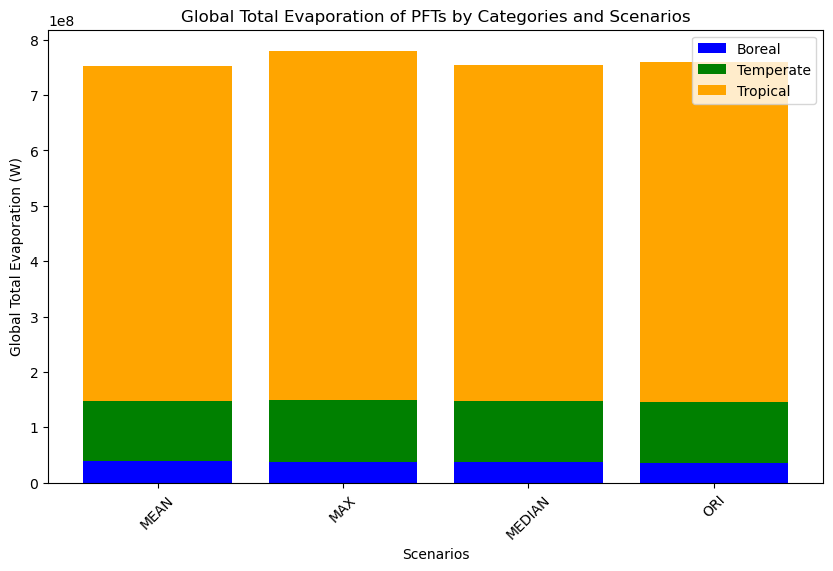

In [24]:
# Define the category dictionary
categories = {
    "Boreal": ["NDT Boreal", "BDT Boreal", "NET Boreal"],
    "Temperate": ["BET Temperate", "BDT Temperate", "NET Temperate"],
    "Tropical": ["BET Tropical", "BDT Tropical"],
}

# Calculate the total value of each category
category_totals = {}
for category, pft_list in categories.items():
    category_totals[category] = {}
    for scenario in scenarios:
        category_totals[category][scenario] = sum(
            [global_totals_EV[scenario][pft_name] for pft_name in pft_list]
        )

# Output results
for category in categories:
    print(f"{category}:")
    for scenario in scenarios:
        print(f"{scenario}: {category_totals[category][scenario]}")
    print()

import matplotlib.pyplot as plt

# Set scene labels and colors
scenarios = ['MEAN_final_2001_to_2011', 'MAX_final_2001_to_2011', 'MEDIAN_final_2001_to_2011', 'ORI_final_2001_to_2011']
colors = {'Boreal': 'blue', 'Temperate': 'green', 'Tropical': 'orange'}
scenarios_tag = ['MEAN', 'MAX', 'MEDIAN', 'ORI']
# Initialize the data for the stacked bar chart
bottoms = {scenario: 0 for scenario in scenarios}

# Draw stacked bars
fig, ax = plt.subplots(figsize=(10, 6),dpi = 100)
for category in categories:
    values = [category_totals[category][scenario] for scenario in scenarios]
    ax.bar(scenarios, values, bottom=[bottoms[scenario] for scenario in scenarios], label=category, color=colors[category])
    for scenario in scenarios:
        bottoms[scenario] += category_totals[category][scenario]
    ax.set_xticklabels(list(scenarios_tag), rotation=45)
    
# Set up titles, labels and legends
ax.set_title('Global Total Evaporation of PFTs by Categories and Scenarios')
ax.set_xlabel('Scenarios')
ax.set_ylabel('Global Total Evaporation (W)')
ax.legend()

# Display graphics
plt.show()


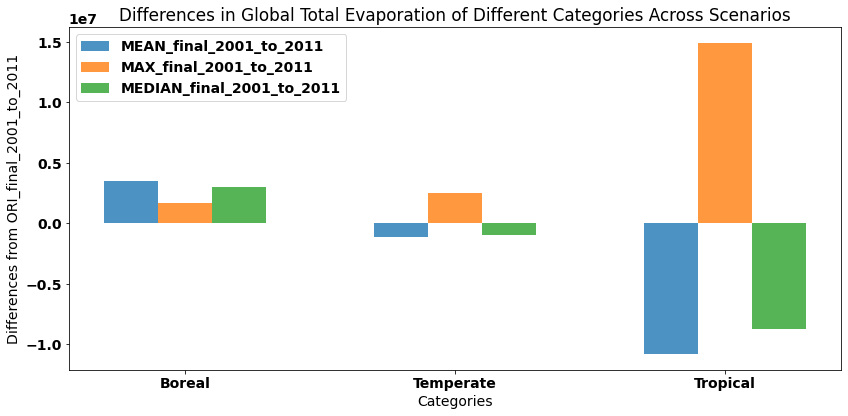

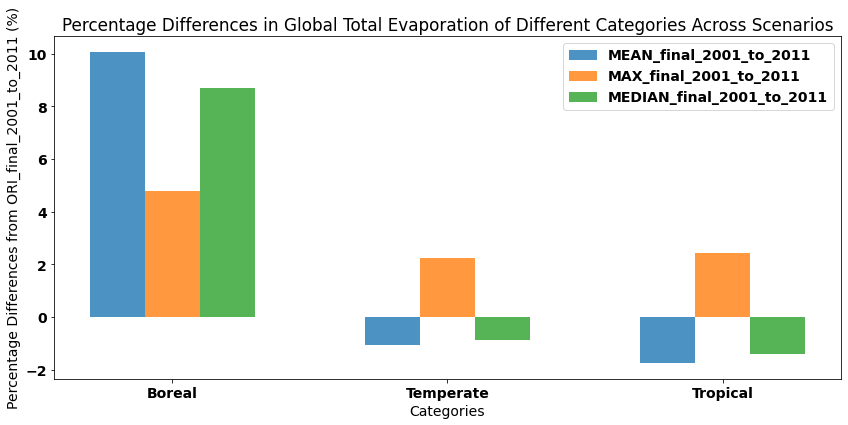

In [30]:
# 1. create a dictionary that maps each PFT to the corresponding category
pft_categories = {}
for pft_name in pft_names:
    if "Boreal" in pft_name:
        pft_categories[pft_name] = "Boreal"
    elif "Temperate" in pft_name:
        pft_categories[pft_name] = "Temperate"
    elif "Tropical" in pft_name:
        pft_categories[pft_name] = "Tropical"

# 2. Calculate global totals for each category
category_totals = {}
for scenario in scenarios:
    category_totals[scenario] = {"Boreal": 0, "Temperate": 0, "Tropical": 0}
    for pft_name in pft_names:
        category = pft_categories[pft_name]
        category_totals[scenario][category] += global_totals_EV[scenario][pft_name]

# 3. calculate the differences between scenarios
reference_scenario = 'ORI_final_2001_to_2011'
category_differences_EV = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    category_differences_EV[scenario] = {}
    for category in ["Boreal", "Temperate", "Tropical"]:
        category_differences_EV[scenario][category] = category_totals[scenario][category] - category_totals[reference_scenario][category]

# 4. visualization results
categories = ["Boreal", "Temperate", "Tropical"]
num_categories = len(categories)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_categories)

plt.figure(figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    if scenario == reference_scenario:
        continue
    category_values = [category_differences_EV[scenario][category] for category in categories]
    plt.bar(index + i * bar_width, category_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('Categories')
plt.ylabel('Differences from ORI_final_2001_to_2011')
plt.title('Differences in Global Total Evaporation of Different Categories Across Scenarios')
plt.xticks(index + bar_width, categories)
plt.legend()

plt.tight_layout()
plt.show()

# 5. Calculate the difference between scenarios (percentage)
reference_scenario = 'ORI_final_2001_to_2011'
category_differences_percentage_EV = {}
for scenario in scenarios:
    if scenario == reference_scenario:
        continue
    category_differences_percentage_EV[scenario] = {}
    for category in ["Boreal", "Temperate", "Tropical"]:
        difference = category_totals[scenario][category] - category_totals[reference_scenario][category]
        category_differences_percentage_EV[scenario][category] = (difference / category_totals[reference_scenario][category]) * 100

# 6. visualization results
categories = ["Boreal", "Temperate", "Tropical"]
num_categories = len(categories)
bar_width = 0.2
opacity = 0.8

index = np.arange(num_categories)

plt.figure(figsize=(12, 6))

for i, scenario in enumerate(scenarios):
    if scenario == reference_scenario:
        continue
    category_values = [category_differences_percentage_EV[scenario][category] for category in categories]
    plt.bar(index + i * bar_width, category_values, bar_width, alpha=opacity, label=scenario)

plt.xlabel('Categories')
plt.ylabel('Percentage Differences from ORI_final_2001_to_2011 (%)')
plt.title('Percentage Differences in Global Total Evaporation of Different Categories Across Scenarios')
plt.xticks(index + bar_width, categories)
plt.legend()

plt.tight_layout()
plt.show()

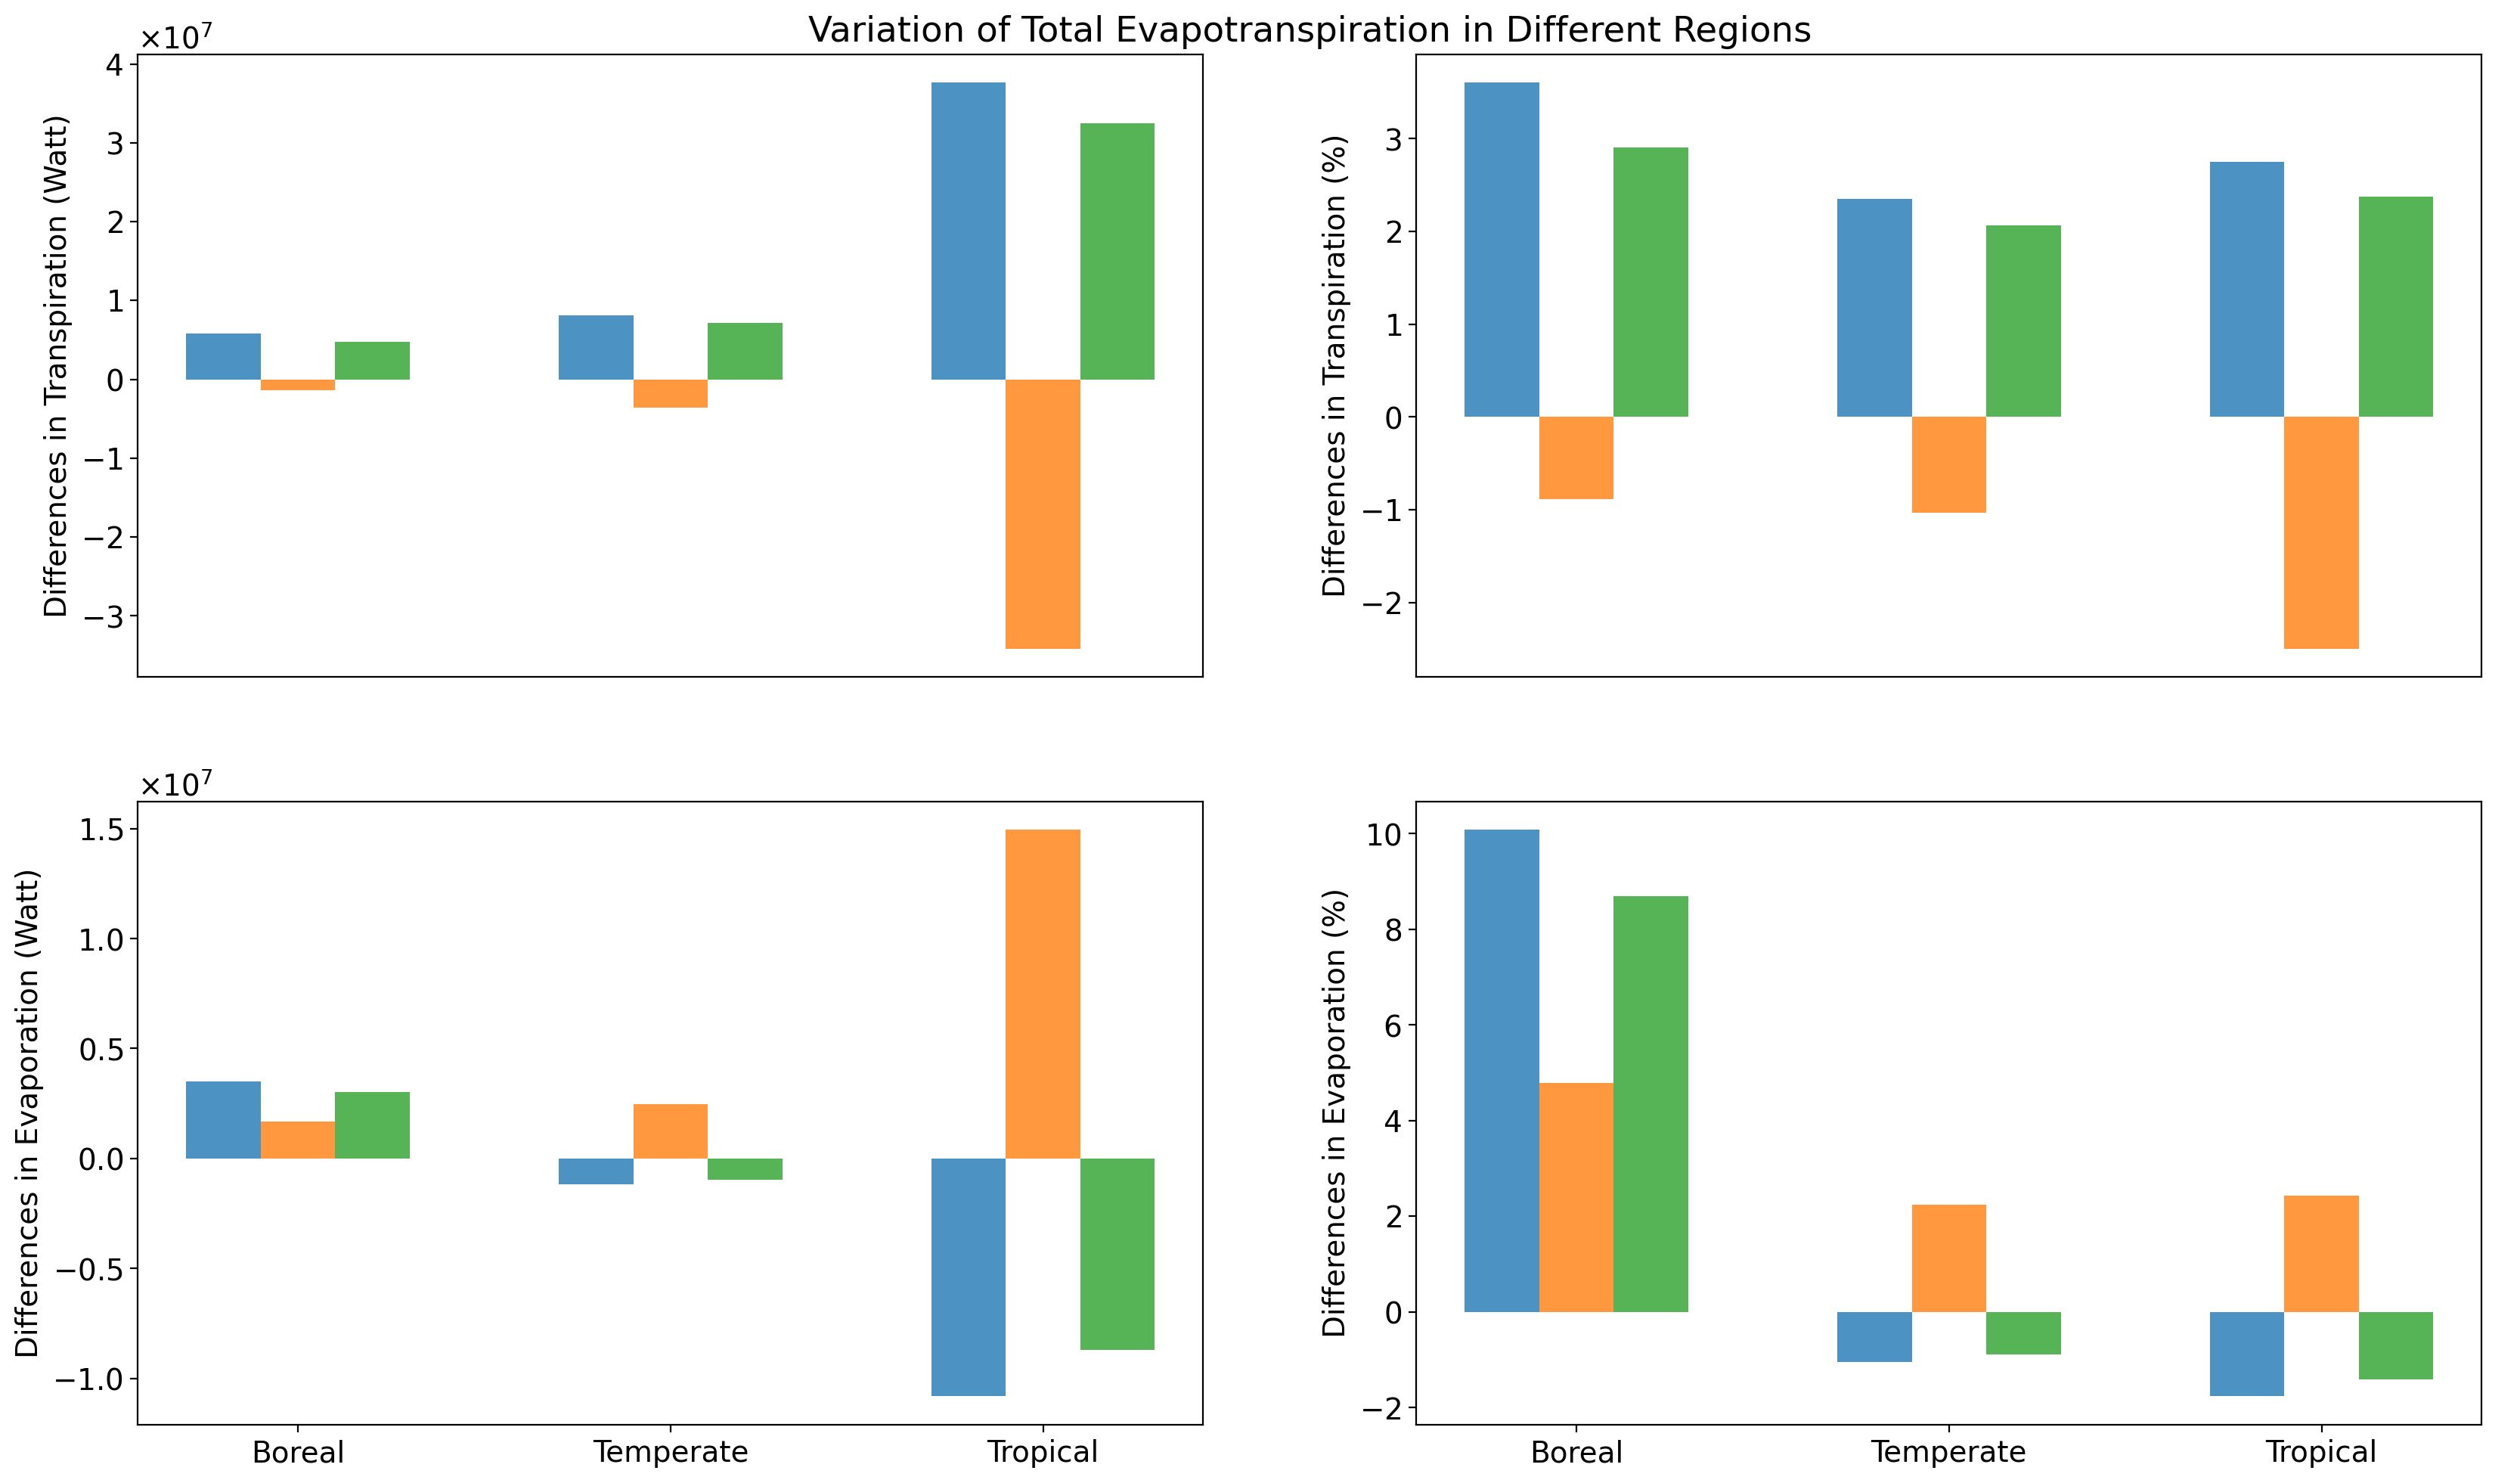

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Set global font size and weight
plt.rcParams.update({'font.size': 14, 'font.weight': 'normal'})

# Set up the figure and axes
fig, axs = plt.subplots(2, 2, figsize=(20, 12), dpi=200)

# Create a large invisible subplot to set a common y-label
ax_big = fig.add_subplot(111, frameon=False)
ax_big.tick_params(labelcolor='none', top=False, bottom=False, left=False, right=False)
ax_big.set_title('Variation of Total Evapotranspiration in Different Regions')

categories = ["Boreal", "Temperate", "Tropical"]
num_categories = len(categories)
bar_width = 0.2
opacity = 0.8
index = np.arange(num_categories)

# Function to create bar plots
def create_bar_plot(ax, data, title):
    for i, scenario in enumerate(scenarios):
        if scenario == reference_scenario:
            continue
        category_values = [data[scenario][category] for category in categories]
        if scenario == scenarios[0]:
            lab = 'Mean'
        if scenario == scenarios[1]:
            lab = 'Max'
        if scenario == scenarios[2]:
            lab = 'Median'
        ax.bar(index + i * bar_width, category_values, bar_width, alpha=opacity, label=lab)

    ax.set_ylabel(title)


# Transpiration - differences
create_bar_plot(axs[0, 0], category_differences, 'Differences in Transpiration (Watt)')

# Transpiration - percentage differences
create_bar_plot(axs[0, 1], category_differences_percentage, 'Differences in Transpiration (%)')

# Evaporation - differences
create_bar_plot(axs[1, 0], category_differences_EV, 'Differences in Evaporation (Watt)')

# Evaporation - percentage differences
create_bar_plot(axs[1, 1], category_differences_percentage_EV, 'Differences in Evaporation (%)')

# Adjust layout and display plot
for i, ax in enumerate(axs.flat):
    formatter = ScalarFormatter(useMathText=True, useOffset=False)
    formatter.set_scientific(True)
    ax.yaxis.set_major_formatter(formatter)
    
    if i >= 2:  # Set x-axis ticks and labels only for the bottom two subplots
        ax.set_xticks(index + bar_width)
        ax.set_xticklabels(categories)
    else:
        ax.set_xticks([])  # Remove x-axis ticks and labels for the top two subplots

plt.show()


mean:
PFT 2: 19.844552748030306
PFT 3: 14.486228543787961
PFT 4: 12.935986066941442
PFT 5: 14.75867201448075
PFT 6: 17.081954085919726
PFT 7: 13.7907212893014
PFT 8: 12.643324583088495
PFT 9: 17.113461694397543

max:
PFT 2: 19.84469841433272
PFT 3: 14.891241002888433
PFT 4: 13.831805287754497
PFT 5: 21.166604807893837
PFT 6: 22.28914616436104
PFT 7: 13.808008434280234
PFT 8: 19.39893946631902
PFT 9: 17.580993212087684

median:
PFT 2: 19.844564248725092
PFT 3: 14.517312922033046
PFT 4: 13.154027446210739
PFT 5: 15.369257184932426
PFT 6: 17.44121418992717
PFT 7: 13.790094615994404
PFT 8: 13.105125721089598
PFT 9: 17.16800256396786

ori:
PFT 2: 19.84460090840881
PFT 3: 14.223369846146914
PFT 4: 12.69839039179445
PFT 5: 22.743818113564902
PFT 6: 22.500823628597356
PFT 7: 13.78046256869442
PFT 8: 19.719994186191254
PFT 9: 17.372215011869926



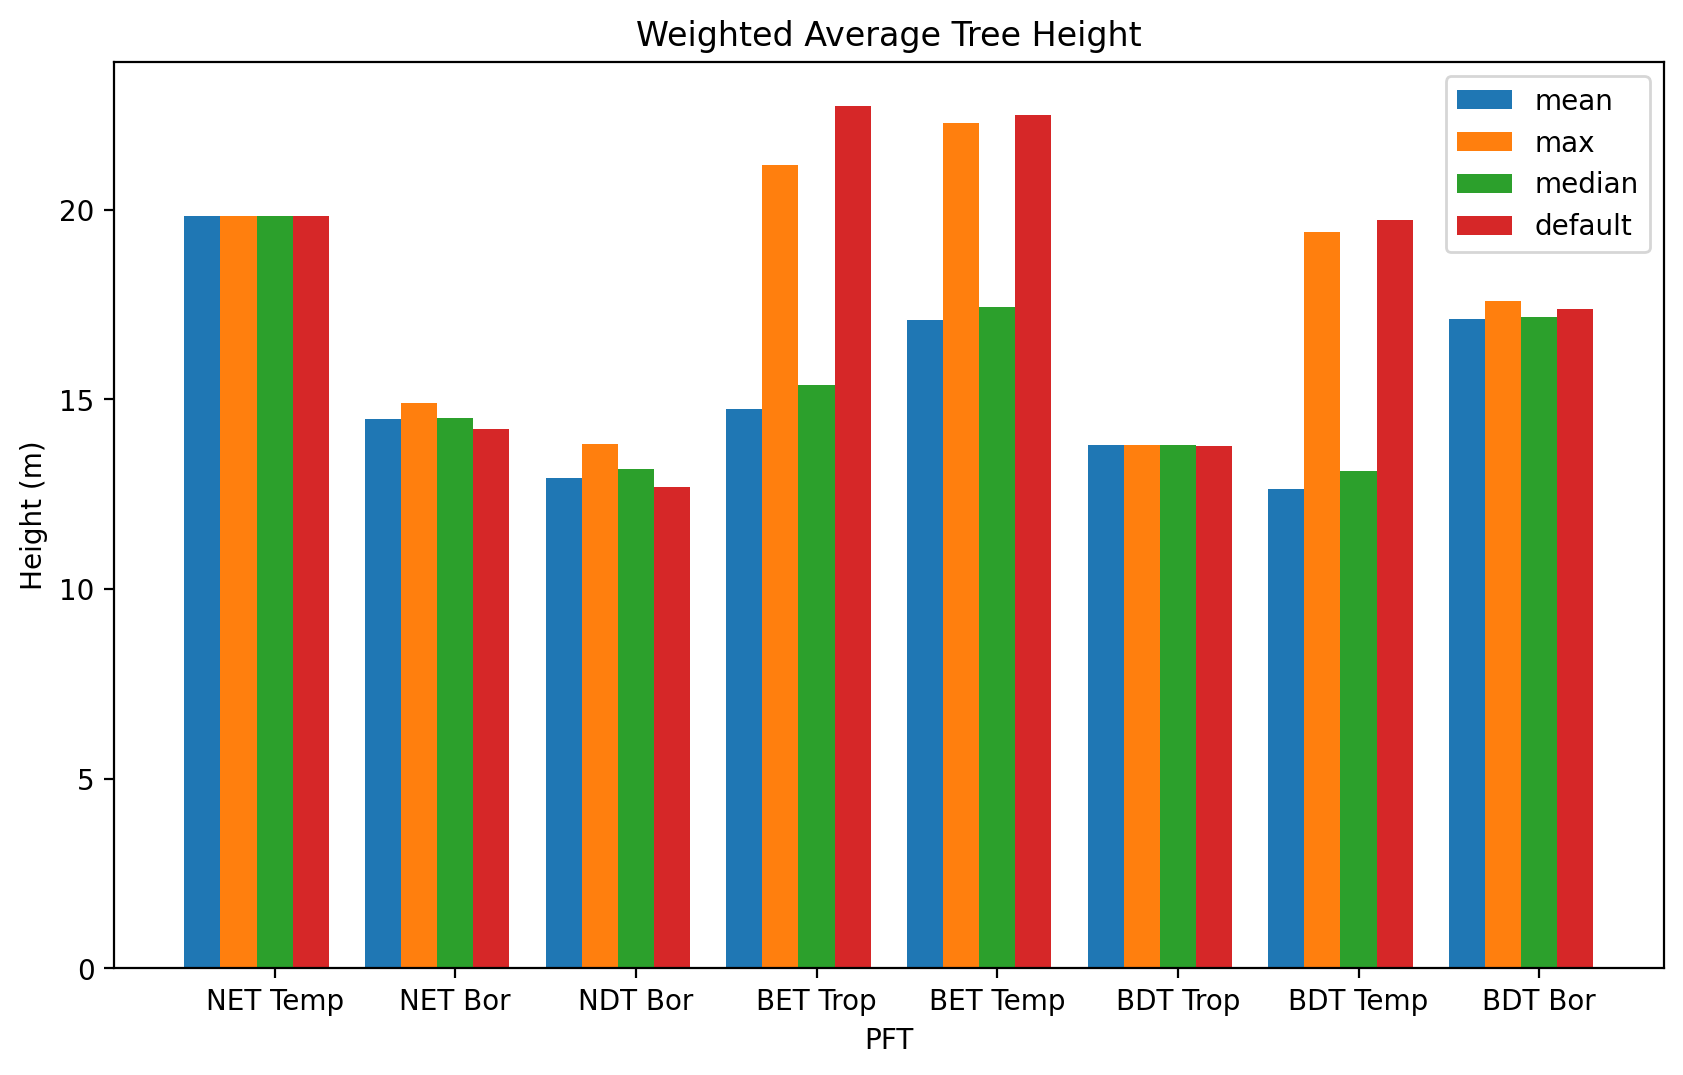

In [234]:
import os
import netCDF4
import numpy as np

file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}

for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables[variable][:]

pft_mapping = {i: i + 1 for i in range(2, 10)}

weighted_heights = {}

for scenario in scenarios:
    weighted_heights[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height

# Output results
for scenario in scenarios:
    print(f"{scenario}:")
    for pft in weighted_heights[scenario]:
        print(f"PFT {pft}: {weighted_heights[scenario][pft][0]}")
    print()

import matplotlib.pyplot as plt

# 计算年均树高
annual_weighted_heights = {}

for scenario in scenarios:
    annual_weighted_heights[scenario] = {}
    for pft in weighted_heights[scenario]:
        annual_weighted_heights[scenario][pft] = np.mean(weighted_heights[scenario][pft], axis=0)

# 可视化年均树高
n_scenarios = len(scenarios)
n_pfts = len(pft_mapping)

fig, ax = plt.subplots(figsize=(10, 6),dpi=200)
bar_width = 0.2
x_positions = np.arange(n_pfts)

for i, scenario in enumerate(scenarios):
    mean_heights = [annual_weighted_heights[scenario][pft] for pft in pft_mapping]
    positions = x_positions + i * bar_width
    ax.bar(positions, mean_heights, width=bar_width, label=scenario)

ax.set_title("Weighted Average Tree Height")
ax.set_ylabel("Height (m)")
ax.set_xlabel("PFT")
ax.set_xticks(x_positions + bar_width * n_scenarios / 2)
ax.set_xticklabels(['NET Temp', 'NET Bor', 'NDT Bor', 'BET Trop', 'BET Temp', 'BDT Trop', 'BDT Temp', 'BDT Bor'])
ax.legend(['mean', 'max', 'median', 'default'])

plt.show()


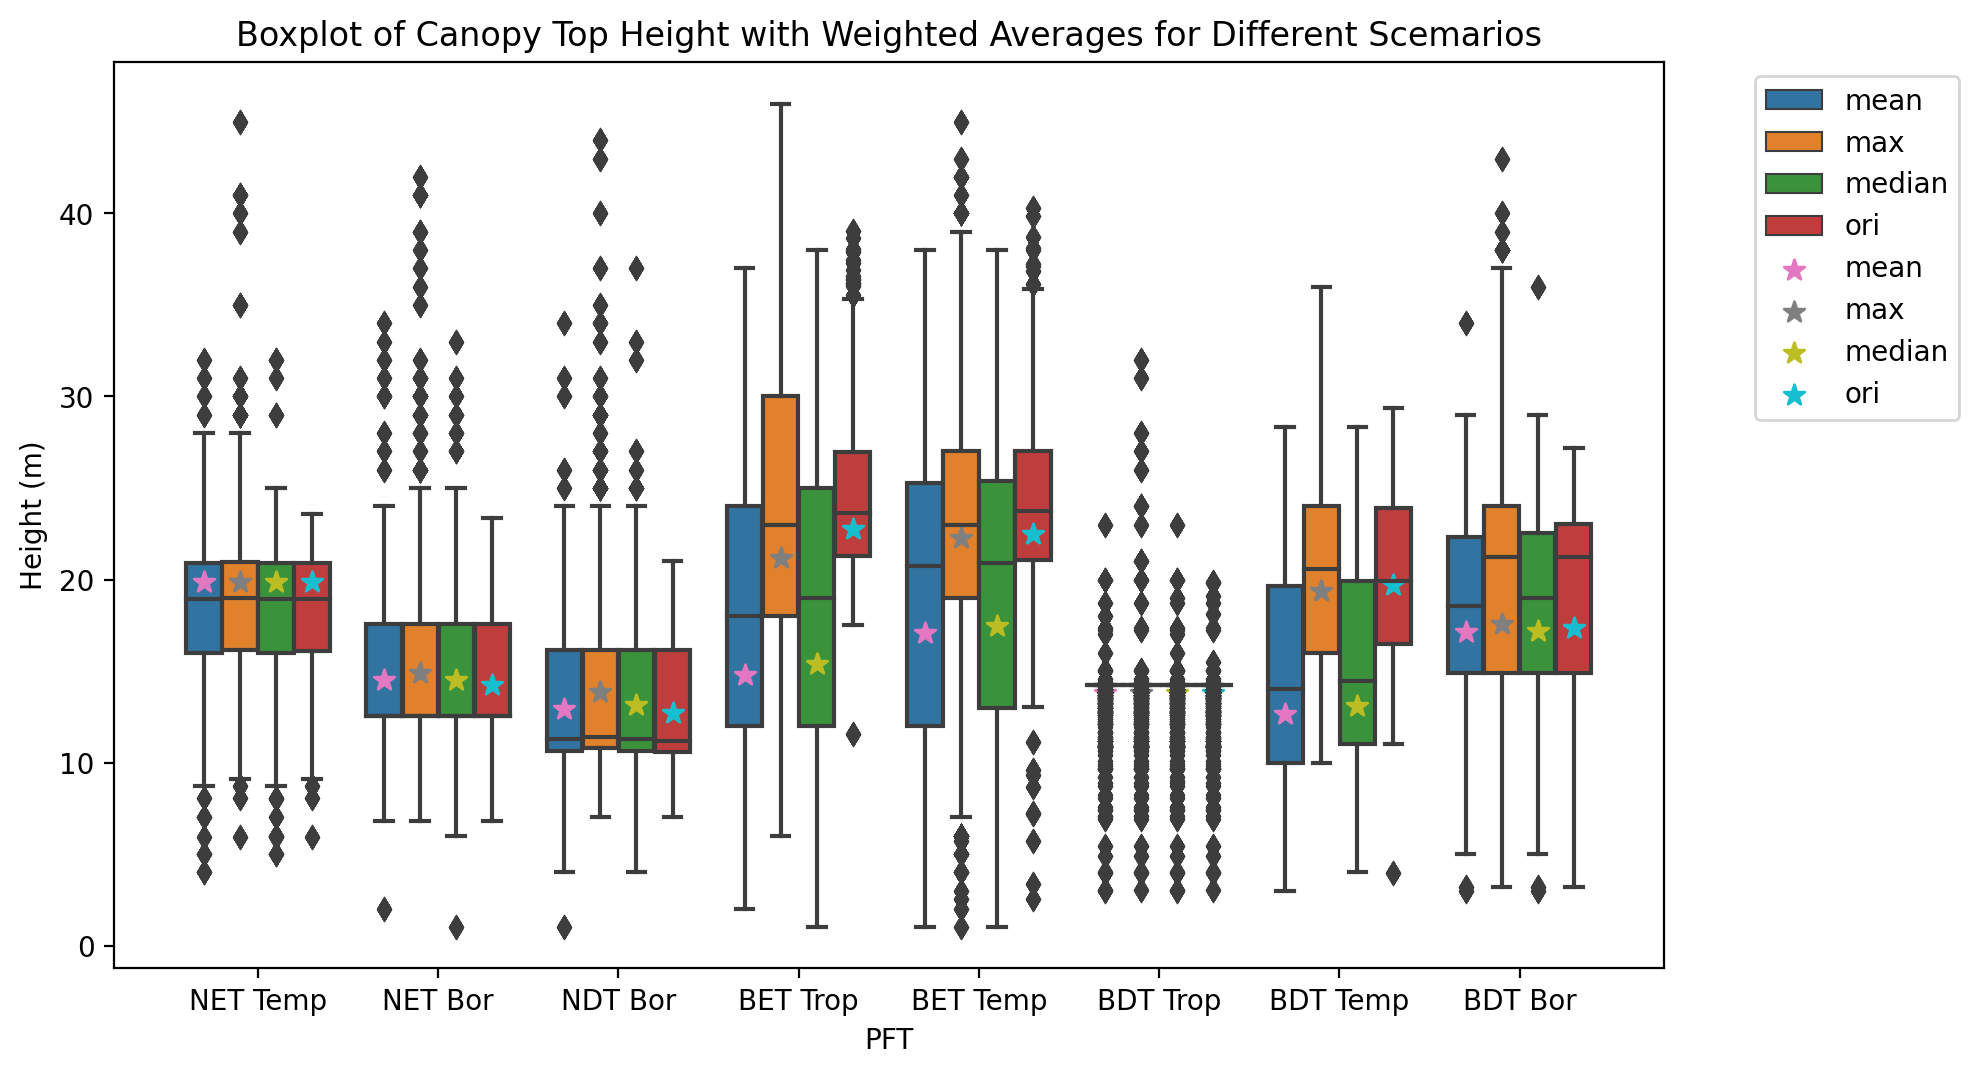

In [57]:
file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}

for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables[variable][:]

pft_mapping = {i: i + 1 for i in range(2, 10)}

weighted_heights = {}

for scenario in scenarios:
    weighted_heights[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height

import matplotlib.pyplot as plt

annual_weighted_heights = {}

for scenario in scenarios:
    annual_weighted_heights[scenario] = {}
    for pft in weighted_heights[scenario]:
        annual_weighted_heights[scenario][pft] = np.mean(weighted_heights[scenario][pft], axis=0)


for i, scenario in enumerate(scenarios):
    mean_heights = [annual_weighted_heights[scenario][pft] for pft in pft_mapping]
    positions = x_positions + i * bar_width
    ax.bar(positions, mean_heights, width=bar_width, label=scenario)

# Prepare the data for the boxplot
box_data = []

for scenario in scenarios:
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]

        for height in monthly_height.flatten():
            box_data.append({
                'Scenario': scenario,
                'PFT': pft,
                'Height': height
            })

box_df = pd.DataFrame(box_data)

# Create a boxplot
plt.figure(figsize=(10, 6), dpi=200)
sns.boxplot(x='PFT', y='Height', hue='Scenario', data=box_df)

# Add the weighted average heights to the boxplot
scatter_data = []
for i, scenario in enumerate(scenarios):
    for j, pft in enumerate(pft_mapping):
        annual_weighted_height = np.mean(weighted_heights[scenario][pft], axis=0)
        scatter_data.append({
            'x': j + i * 0.2 - 0.3,
            'y': annual_weighted_height,
            'marker': '*',
            's': 60,
            'color': sns.color_palette()[i+6],
            'label': scenario if j == 0 else None
        })

for data in scatter_data:
    plt.scatter(**data)

plt.title("Boxplot of Canopy Top Height with Weighted Averages for Different Scemarios")
plt.xlabel("PFT")
plt.ylabel("Height (m)")
plt.xticks(ticks=np.arange(n_pfts), labels=['NET Temp', 'NET Bor', 'NDT Bor', 'BET Trop', 'BET Temp', 'BDT Trop', 'BDT Temp', 'BDT Bor'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

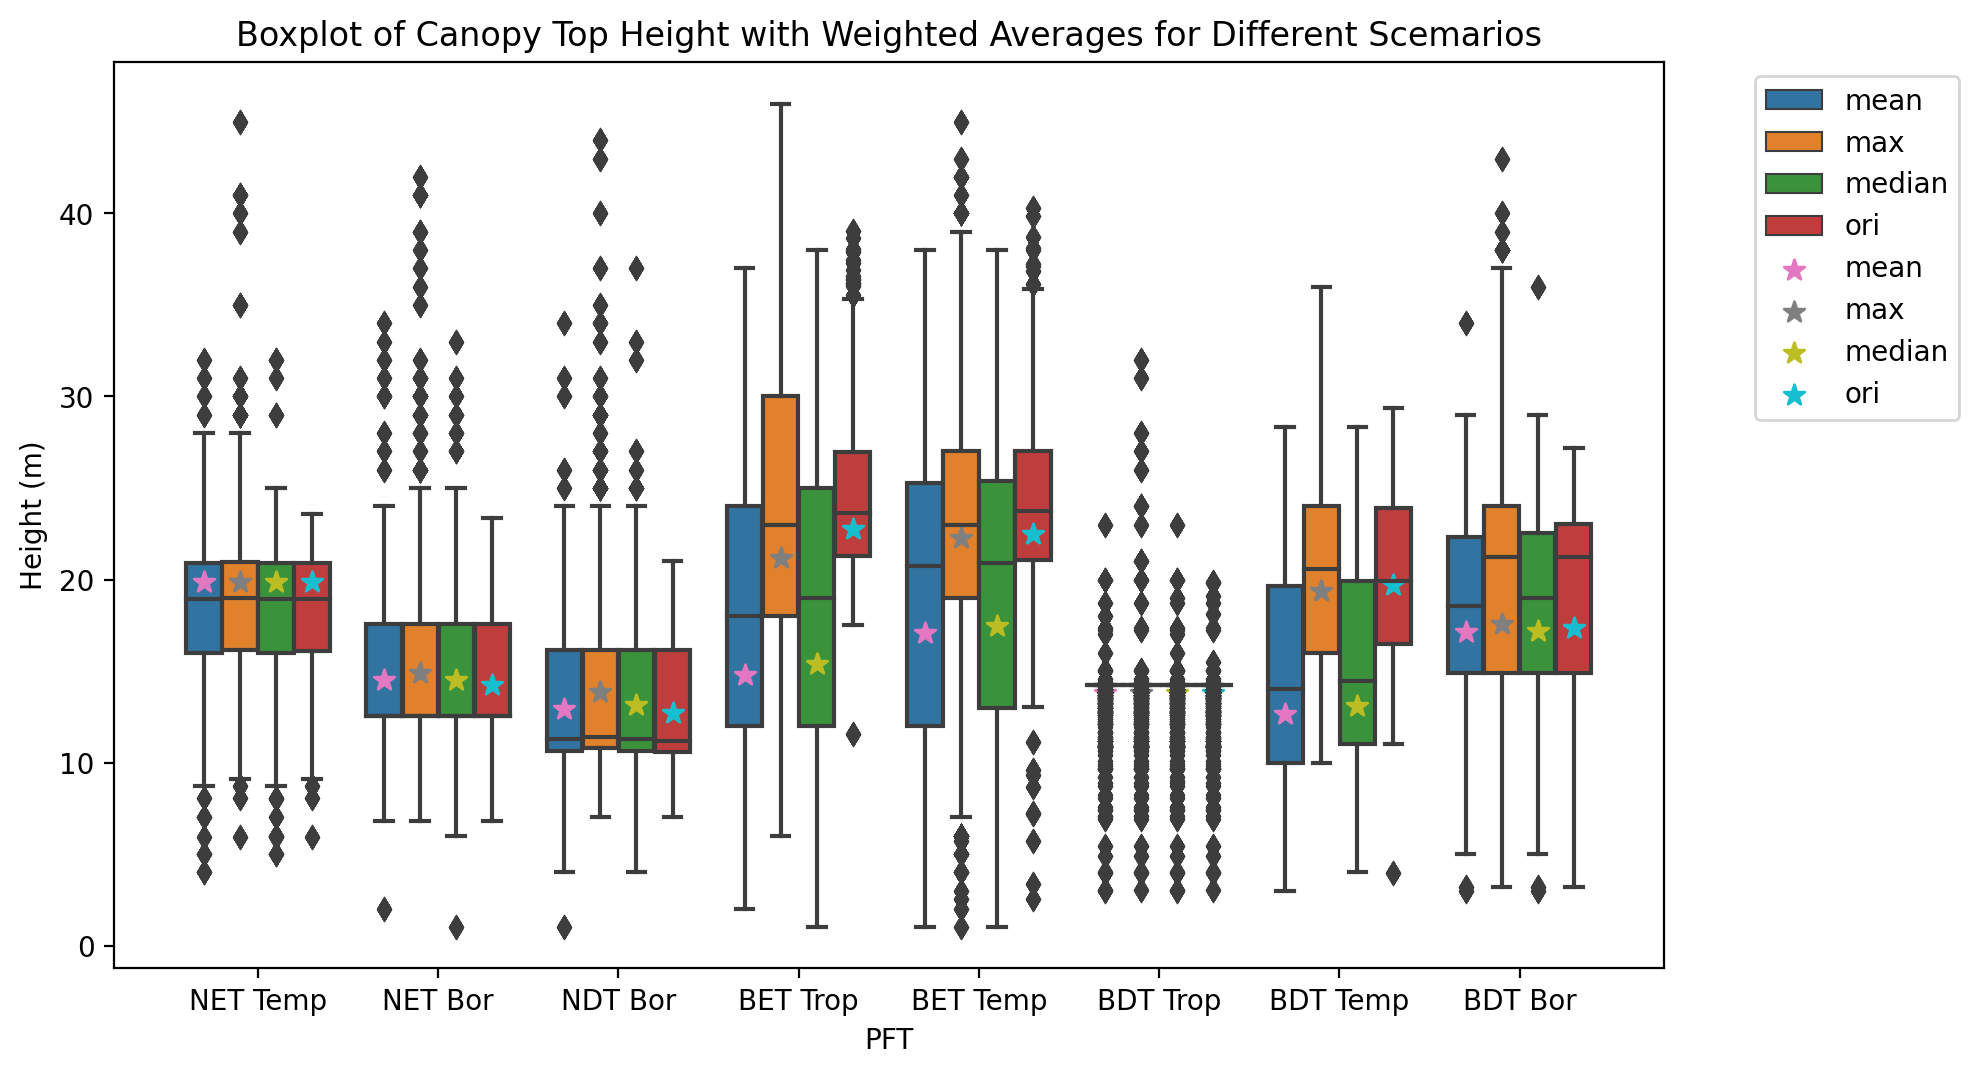

In [267]:
file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}

for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables[variable][:]

pft_mapping = {i: i + 1 for i in range(2, 10)}

weighted_heights = {}

for scenario in scenarios:
    weighted_heights[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height

import matplotlib.pyplot as plt

annual_weighted_heights = {}

for scenario in scenarios:
    annual_weighted_heights[scenario] = {}
    for pft in weighted_heights[scenario]:
        annual_weighted_heights[scenario][pft] = np.mean(weighted_heights[scenario][pft], axis=0)


for i, scenario in enumerate(scenarios):
    mean_heights = [annual_weighted_heights[scenario][pft] for pft in pft_mapping]
    positions = x_positions + i * bar_width
    ax.bar(positions, mean_heights, width=bar_width, label=scenario)

# Prepare the data for the boxplot
box_data = []

for scenario in scenarios:
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]

        for height in monthly_height.flatten():
            box_data.append({
                'Scenario': scenario,
                'PFT': pft,
                'Height': height
            })

box_df = pd.DataFrame(box_data)

# Create a boxplot
plt.figure(figsize=(10, 6), dpi=200)
sns.boxplot(x='PFT', y='Height', hue='Scenario', data=box_df)

# Add the weighted average heights to the boxplot
scatter_data = []
for i, scenario in enumerate(scenarios):
    for j, pft in enumerate(pft_mapping):
        annual_weighted_height = np.mean(weighted_heights[scenario][pft], axis=0)
        scatter_data.append({
            'x': j + i * 0.2 - 0.3,
            'y': annual_weighted_height,
            'marker': '*',
            's': 60,
            'color': sns.color_palette()[i+6],
            'label': scenario if j == 0 else None
        })

for data in scatter_data:
    plt.scatter(**data)

plt.title("Boxplot of Canopy Top Height with Weighted Averages for Different Scemarios")
plt.xlabel("PFT")
plt.ylabel("Height (m)")
plt.xticks(ticks=np.arange(n_pfts), labels=['NET Temp', 'NET Bor', 'NDT Bor', 'BET Trop', 'BET Temp', 'BDT Trop', 'BDT Temp', 'BDT Bor'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

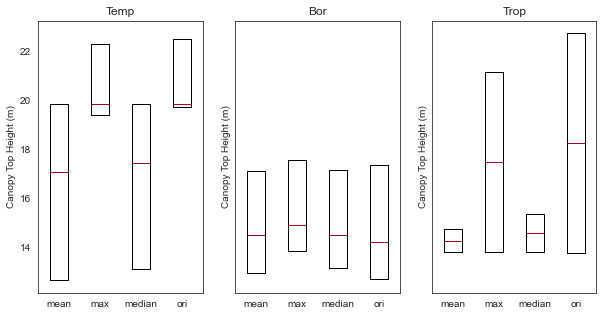

In [290]:
file_path = 'H:/CLM_input/'
scenarios = ['mean', 'max', 'median', 'ori']
variable = 'MONTHLY_HEIGHT_TOP'

data = {}

for scenario in scenarios:
    nc_file = os.path.join(file_path, f"{scenario}.nc")
    with netCDF4.Dataset(nc_file, 'r') as ds:
        data[scenario] = ds.variables[variable][:]

pft_mapping = {i: i + 1 for i in range(2, 10)}

weighted_heights = {}

for scenario in scenarios:
    weighted_heights[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height

wh = {}
for scenario in scenarios:
    weighted_heights[scenario] = {}
    wh[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height

        if pft in [2, 6, 8]:
            wh[scenario]['temp'] = wh.get(scenario, {}).get('temp', []) + weighted_monthly_height.tolist()
        elif pft in [3, 4, 9]:
            wh[scenario]['bor'] = wh.get(scenario, {}).get('bor', []) + weighted_monthly_height.tolist()
        elif pft in [5, 7]:
            wh[scenario]['trop'] = wh.get(scenario, {}).get('trop', []) + weighted_monthly_height.tolist()

import matplotlib.pyplot as plt

# Create boxplots for each region and scenario
fig, axs = plt.subplots(1, 3, figsize=(10, 5), sharey=True)

for i, region in enumerate(['temp', 'bor', 'trop']):
    data = [wh[scenario][region] for scenario in scenarios]
    axs[i].boxplot(data)
    axs[i].set_xticklabels(scenarios)
    axs[i].set_title(region.capitalize())
    axs[i].set_ylabel("Canopy Top Height (m)")

plt.show()


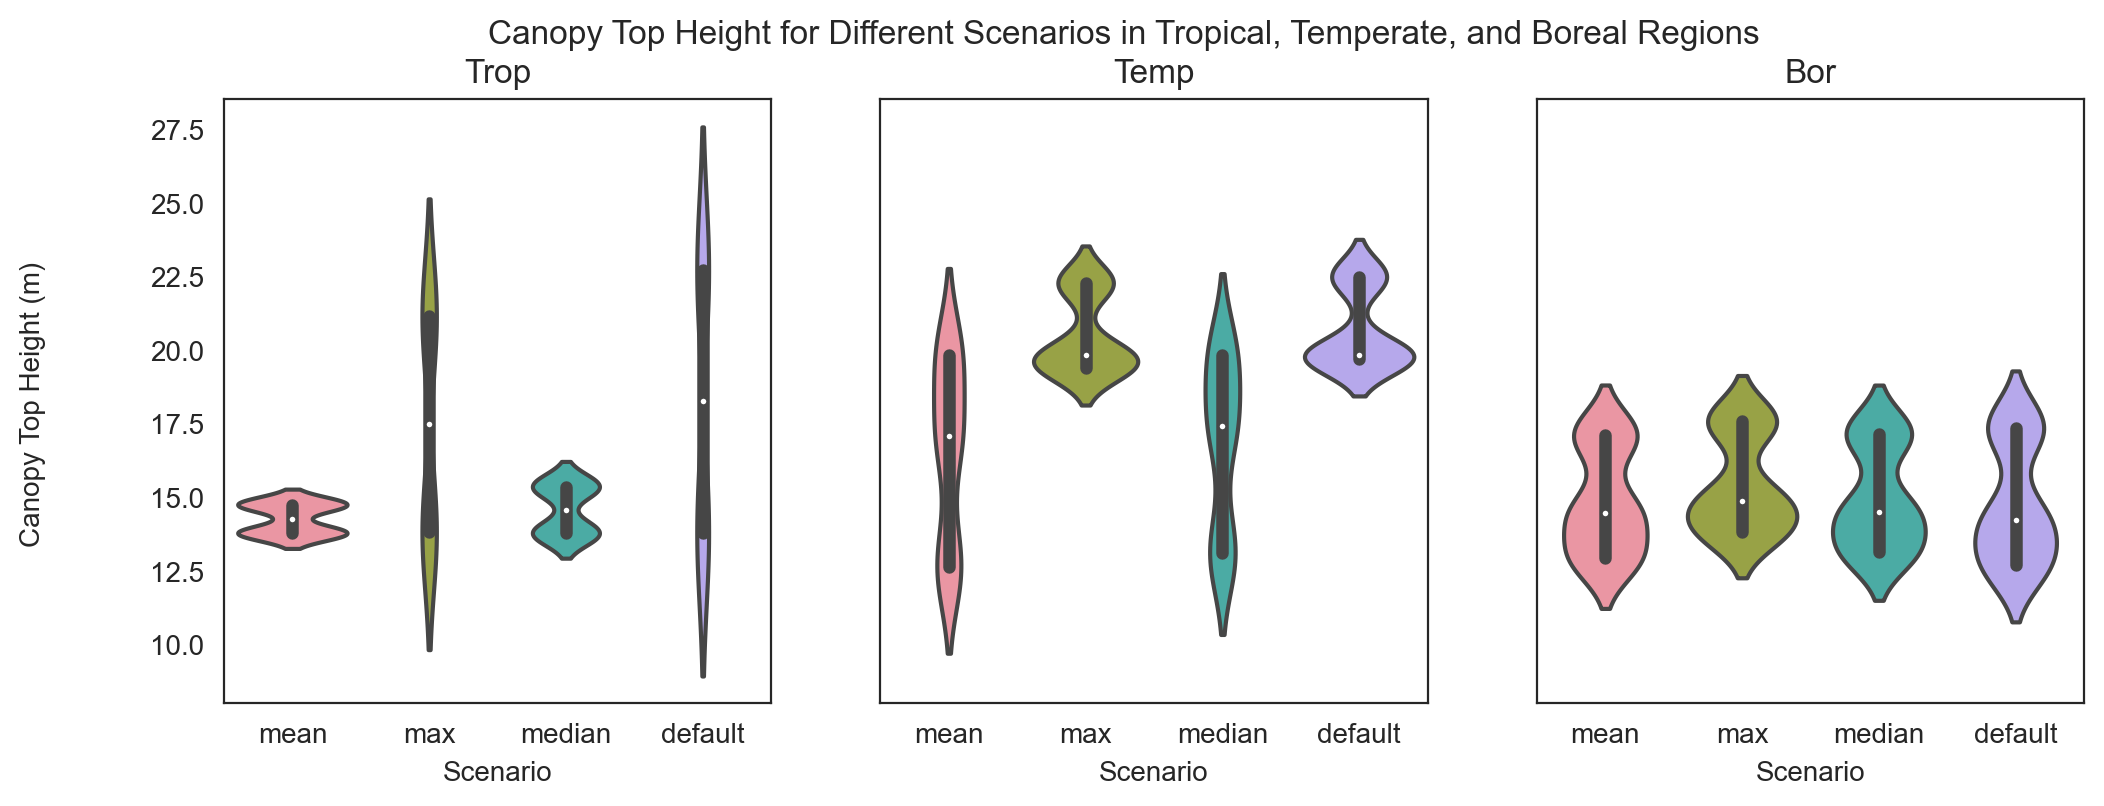

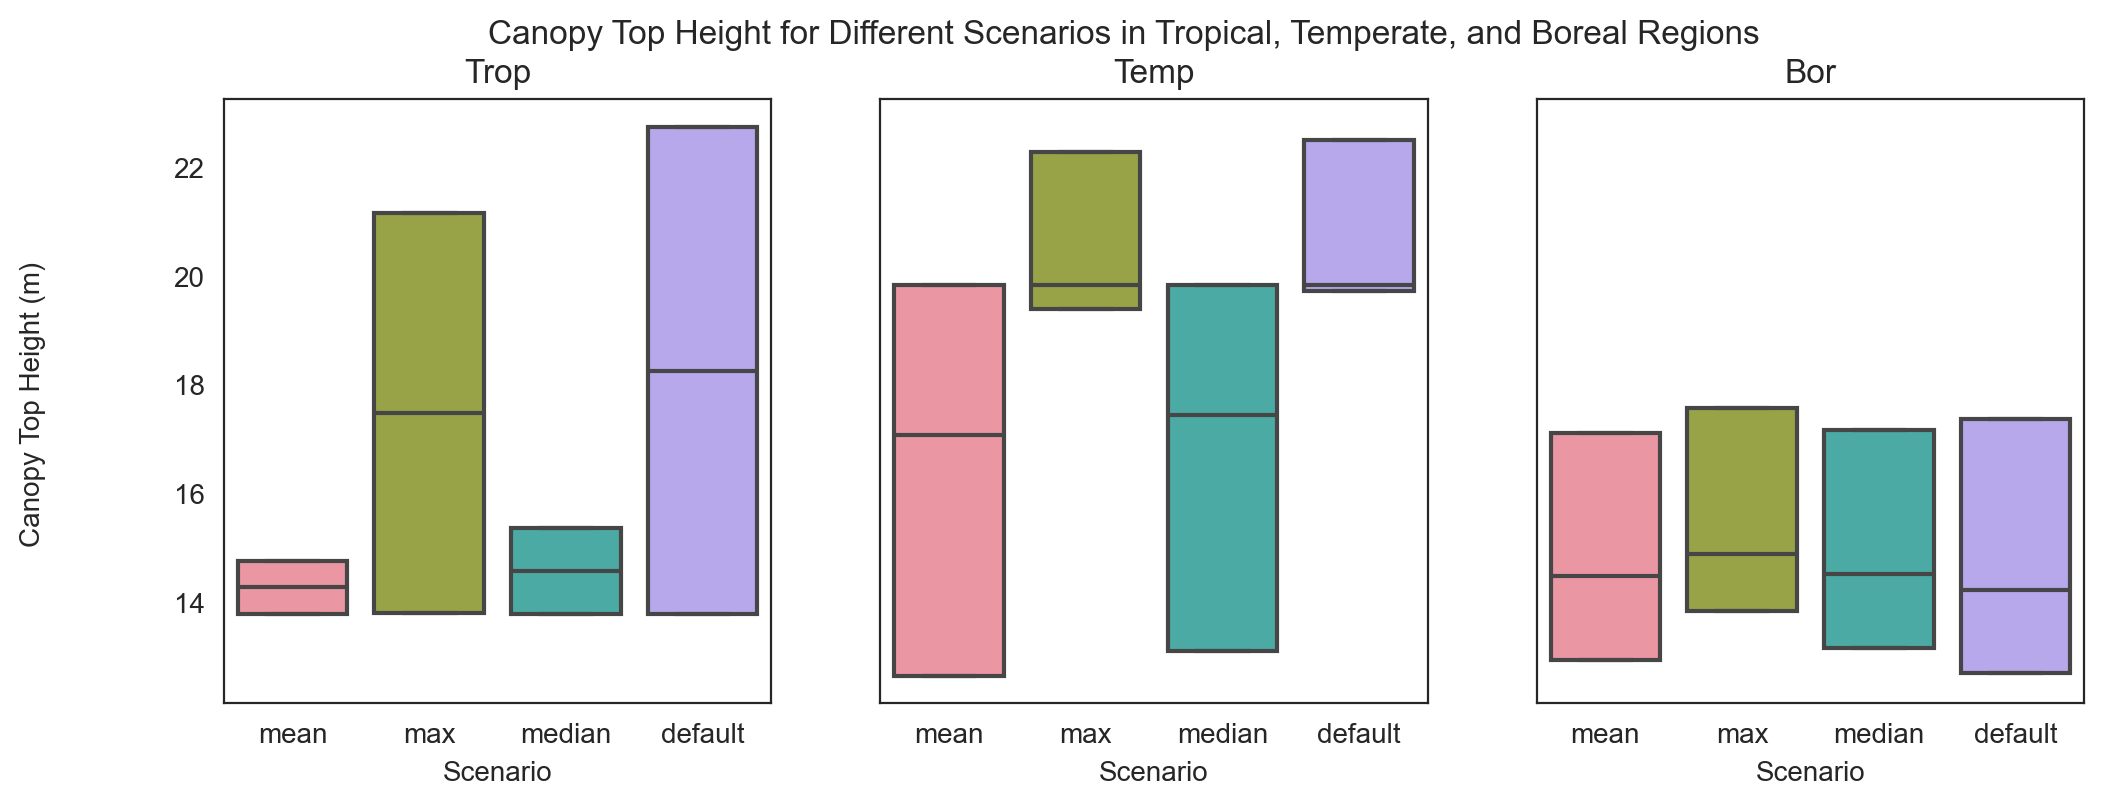

In [314]:
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import os
import netCDF4
import matplotlib.pyplot as plt
import seaborn as sns

# data for the boxplot
wh = {
    'mean': {
        'temp': np.concatenate([weighted_heights['mean'][2], weighted_heights['mean'][6], weighted_heights['mean'][8]]),
        'bor': np.concatenate([weighted_heights['mean'][3], weighted_heights['mean'][4], weighted_heights['mean'][9]]),
        'trop': np.concatenate([weighted_heights['mean'][5], weighted_heights['mean'][7]])
    },
    'max': {
        'temp': np.concatenate([weighted_heights['max'][2], weighted_heights['max'][6], weighted_heights['max'][8]]),
        'bor': np.concatenate([weighted_heights['max'][3], weighted_heights['max'][4], weighted_heights['max'][9]]),
        'trop': np.concatenate([weighted_heights['max'][5], weighted_heights['max'][7]])
    },
    'median': {
        'temp': np.concatenate([weighted_heights['median'][2], weighted_heights['median'][6], weighted_heights['median'][8]]),
        'bor': np.concatenate([weighted_heights['median'][3], weighted_heights['median'][4], weighted_heights['median'][9]]),
        'trop': np.concatenate([weighted_heights['median'][5], weighted_heights['median'][7]])
    },
    'ori': {
        'temp': np.concatenate([weighted_heights['ori'][2], weighted_heights['ori'][6], weighted_heights['ori'][8]]),
        'bor': np.concatenate([weighted_heights['ori'][3], weighted_heights['ori'][4], weighted_heights['ori'][9]]),
        'trop': np.concatenate([weighted_heights['ori'][5], weighted_heights['ori'][7]])
    }
}

# Create a figure with three subplots, one for each region
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, dpi=200)

# Loop through each region and create a boxplot for each scenario in the corresponding subplot
for i, region in enumerate(['trop', 'temp', 'bor']):
    data = [wh[scenario][region] for scenario in scenarios]
    sns.violinplot(data=data, ax=axs[i], scale_hue=True)
    axs[i].set_title(region.capitalize())
    axs[i].set_xlabel('Scenario')
    axs[i].set_xticklabels(['mean', 'max', 'median', 'default'])

# Add a common y-axis label and a title for the entire figure
fig.text(0.04, 0.5, 'Canopy Top Height (m)', va='center', rotation='vertical')
fig.suptitle('Canopy Top Height for Different Scenarios in Tropical, Temperate, and Boreal Regions')

# Show the plot
plt.show()

# Create a figure with three subplots, one for each region
fig, axs = plt.subplots(1, 3, figsize=(12, 4), sharey=True, dpi=200)

# Loop through each region and create a boxplot for each scenario in the corresponding subplot
for i, region in enumerate(['trop', 'temp', 'bor']):
    data = [wh[scenario][region] for scenario in scenarios]
    sns.boxplot(data=data, ax=axs[i])
    axs[i].set_title(region.capitalize())
    axs[i].set_xlabel('Scenario')
    axs[i].set_xticklabels(['mean', 'max', 'median', 'default'])

# Add a common y-axis label and a title for the entire figure
fig.text(0.04, 0.5, 'Canopy Top Height (m)', va='center', rotation='vertical')
fig.suptitle('Canopy Top Height for Different Scenarios in Tropical, Temperate, and Boreal Regions')

# Show the plot
plt.show()

In [26]:
for scenario in scenarios:
    weighted_heights[scenario] = {}
    for pft in pft_mapping:
        pft_indexes = np.where(pfts1d_itype_veg == pft_mapping[pft])[0]
        weight = pfts1d_wtgcell[pft_indexes]

        print(f"Scenario: {scenario}, PFT: {pft}, Weights: {weight}")  # Add this line to print weights

        monthly_height = data[scenario][:, pft - 1, pfts1d_jxy[pft_indexes] - 1, pfts1d_ixy[pft_indexes] - 1]
        weighted_monthly_height = np.average(monthly_height, axis=1, weights=weight)

        weighted_heights[scenario][pft] = weighted_monthly_height


Scenario: mean, PFT: 2, Weights: [2.03970942e-04 4.73281640e-05 5.19448591e-05 ... 8.44854098e-07
 2.77124965e-05 3.26082179e-05]
Scenario: mean, PFT: 3, Weights: [4.88051425e-02 2.03742984e-04 5.10196765e-02 ... 9.70063032e-04
 3.25147569e-05 2.14420227e-05]
Scenario: mean, PFT: 4, Weights: [5.23567813e-02 1.68770430e-01 7.06290903e-02 9.06883902e-02
 7.41155408e-02 2.44710987e-01 7.66592774e-02 9.81472468e-02
 6.91963275e-02 7.85270936e-02 1.24214586e-01 1.25865917e-01
 5.40700913e-04 1.06867449e-01 1.71443265e-02 2.37668183e-02
 2.24039732e-02 9.97645083e-04 1.61824435e-01 3.48015107e-02
 1.60378021e-02 1.40311843e-02 1.89760018e-02 3.38916396e-01
 2.97464331e-01 3.64498263e-01 8.52074030e-02 1.71429392e-02
 2.08711168e-02 1.92863509e-02 1.55019098e-01 5.92894680e-02
 1.29416300e-01 2.51717721e-01 1.74526721e-02 1.30704171e-02
 2.60980954e-02 8.60451511e-01 5.73421938e-01 1.65877942e-01
 3.57123745e-01 3.15924945e-01 1.75060450e-02 1.43525353e-02
 2.10165083e-02 3.41588010e-02 7.847

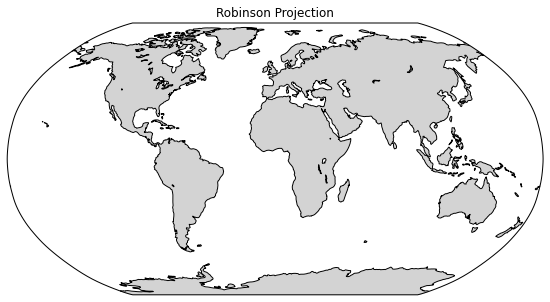

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

# Create a Robinson projection map with coastlines
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_title('Robinson Projection')
ax.coastlines()

# Add land, ocean, and lakes
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='white')
ax.add_feature(cfeature.LAKES, facecolor='white', edgecolor='black')

plt.show()